In [1]:
import os
import glob
import numpy as np
import random
import pandas as pd
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

import scipy.signal as ssig

from sklearn.metrics import auc
import itertools

import scipy.ndimage as scnd
import scipy.stats as sstat
from statsmodels.formula.api import mixedlm

import mz_LFP_functions as mz_LFP
import mz_ephys_unit_analysis as mz_ena

In [2]:
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif'] 

rc_pub={'font.size': 20, 'axes.labelsize': 20, 'legend.fontsize': 20, 
        'axes.titlesize': 25, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 
        'axes.linewidth':1.5, 'lines.linewidth': 2.0,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}

# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc=rc_pub)
    sns.set_style("ticks", {"xtick.major.size": 5, "ytick.major.size": 5})

# to restore the defaults, call plt.rcdefaults() 
set_pub_plots()

# Base variables
This is primarily base values for ephys data

In [3]:
insert_depth = 3100  #change this as appropriate
sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)
CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered

v1_ch = 260
hpc_ch = 110

# Load ephys data
output
- all_trial_lfp <- dataframe of the LFPs for each trial with a 2-d array (#ch x #samp)
- vr_units <- dataframe of all vr units psth
- units_fft <- dataframe of all vr units power spectrum analysis

## LFP

In [4]:
all_trial_lfp = pd.read_pickle(r'G:\Neuropixels\02_wtfx_behavior\all_trials.pkl')
display(all_trial_lfp.head())
print(all_trial_lfp.group.unique(), all_trial_lfp.stim_id.unique())
print(all_trial_lfp.groupby('group')['et'].nunique())

,et,cc,group,trial,lfp_data,stim_id
0,CC067431_HP2,CC067431,FX,0,"[[125.99329, 120.050354, 137.86186, 156.05075,...",0
1,CC067431_HP2,CC067431,FX,1,"[[-57.64133, -62.18796, -66.814, -47.926105, -...",2
2,CC067431_HP2,CC067431,FX,2,"[[248.25328, 276.9713, 268.24234, 259.49213, 2...",2
3,CC067431_HP2,CC067431,FX,3,"[[20.10936, -21.454906, 11.712197, 11.960759, ...",0
4,CC067431_HP2,CC067431,FX,4,"[[56.30739, 51.755466, 75.49548, 66.68102, 67....",0


['FX' 'WT'] ['0' '2' '1']
group
FX     8
WT    10
Name: et, dtype: int64


## Units

### PSTH dataframe

In [346]:
final_df = pd.read_parquet(r"U:\Papers\FX Behavior paper\data\final_V1HPC_OperantNovel_psth.parquet")
vr_units = final_df[final_df.visRes == 'yes']
vr_units.head()

,stim_id,times,cuid,depth,Hz,zscore,ztc,region,group,cc,et,r_groups,visRes
0,0,0.00,CC067431_HP2_248,740,2.543532,-0.865956,-2.264451,hippo,FX,CC067431,CC067431_HP2,0,yes
1,0,0.01,CC067431_HP2_248,740,2.918449,-0.811714,-1.841745,hippo,FX,CC067431,CC067431_HP2,0,yes
2,0,0.02,CC067431_HP2_248,740,3.278977,-0.759553,-1.435263,hippo,FX,CC067431,CC067431_HP2,0,yes
3,0,0.03,CC067431_HP2_248,740,3.651381,-0.705674,-1.015391,hippo,FX,CC067431,CC067431_HP2,0,yes
4,0,0.04,CC067431_HP2_248,740,4.026938,-0.651339,-0.591964,hippo,FX,CC067431,CC067431_HP2,0,yes


In [347]:
print(vr_units.region.unique(), vr_units.group.unique(), vr_units.stim_id.unique())
print(vr_units.groupby('group')['et'].nunique())

['hippo' 'v1'] ['FX' 'WT'] [0 1 2 9]
group
FX     8
WT    10
Name: et, dtype: int64


### Create units FFT dataframe

In [348]:
def get_unit_fft(unit_df):
    unit_arr = unit_df[(unit_df.times>0.5)&(unit_df.times<1.8)].zscore.values
    freq = np.arange(unit_arr.shape[0]) / unit_arr.shape[0] * 100
    freq = freq[:freq.shape[0]//2]
    f = np.fft.fft(unit_arr)
    magnitude_spectrum = (np.abs(f)[:freq.shape[0]])
    return freq, magnitude_spectrum

In [349]:
units_fft = []
for unit,df in vr_units.groupby(['stim_id','cuid']):
    fft_freq, fft_amp = get_unit_fft(df)
    bands = [[2,4],[4,8],[8,12],[12,30],[30,70]]
    auc_val,band_val = [],[]
    for ran in bands:
        lower = fft_freq.searchsorted(ran[0], 'left')
        upper = fft_freq.searchsorted(ran[1], 'right') -1
        val = auc(fft_freq[lower:upper],fft_amp[lower:upper])
        auc_val.append(val)
        band_val.append(str(ran))
    units_fft.append(pd.DataFrame({'band': band_val, 'auc': auc_val, 'cuid': unit[1], 
                                  'stim': unit[0], 'group': df.group.unique()[0],
                                  'region': df.region.unique()[0], 'et': df.et.unique()[0]}))
units_fft = pd.concat(units_fft)

# Load behavior data
output
- behavior <- dataframe of trials and behavior label for each mouse

In [6]:
behavior = pd.read_pickle(r"G:\Neuropixels\02_wtfx_behavior\lick_behavior_rec.pkl")
#replace et CC067431_HP3 with CC067432_HP3 (*this was mislabeled originally)
behavior.loc[behavior["et"] == "CC067431_HP3", "et"] = "CC067432_HP3"
#the stim_id col currently on the df is off, update with true stim_id below
behavior = behavior.drop('stim_id', axis=1) 

In [7]:
# Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
              0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1, 
              0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
              0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
              1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
              0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

# Psuedo random distribution of water to the rewarded stimuli
# 0 -- water given -- 80 times
# 1 -- no water given -- 20 times
rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
             0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
             0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
             0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

overall_order, i = {}, 0
for idx,val in enumerate(stim_order):
    if val == 0:
        if rew_order[i] == 0:
            overall_order[idx]='Go+' #rew
        elif rew_order[i] == 1:
            overall_order[idx]='Go-' #rew2
        i+=1
    elif val == 1:
        overall_order[idx]='No-Go' #unrew

In [8]:
#update the stim_id column with the overall order dictionary made above
display(behavior.head(2))
behavior['stim_id'] = behavior['true_tr'].map(overall_order)
display(behavior.head(2))

,trial,lick_idx,lick_time,true_tr,et,cc
0,1,0,-1.899998,3,CC067431_HP2,CC067431
1,1,1,-1.509998,3,CC067431_HP2,CC067431


,trial,lick_idx,lick_time,true_tr,et,cc,stim_id
0,1,0,-1.899998,3,CC067431_HP2,CC067431,Go+
1,1,1,-1.509998,3,CC067431_HP2,CC067431,Go+


In [9]:
#add behavior outcome for each trial based on the stimulus and if licked 2+ times from [0, 1.2] sec
beh_ls = []
for d,dd in behavior.groupby(['et','trial']):
    lt = dd.lick_time.values
    did_lick = True if sum((lt>0)&(lt<1.2))>=2 else False #checks licks that are between [0, 1.2] time window
    stim = dd.stim_id.unique()[0]
    if stim == 'Go+':
        beh_ls.append(['H']*dd.shape[0] if did_lick else ['M']*dd.shape[0])
    elif stim == 'Go-':
        beh_ls.append(['H']*dd.shape[0] if did_lick else ['M']*dd.shape[0])
    else:
        beh_ls.append(['FA']*dd.shape[0] if did_lick else ['CR']*dd.shape[0])
behavior['behav'] = list(itertools.chain(*beh_ls)) #itertools flattens the list of lists to add to the dataframe
print(behavior.behav.unique())
behavior.head()

['M' 'H' 'CR' 'FA']


,trial,lick_idx,lick_time,true_tr,et,cc,stim_id,behav
0,1,0,-1.899998,3,CC067431_HP2,CC067431,Go+,M
1,1,1,-1.509998,3,CC067431_HP2,CC067431,Go+,M
2,1,2,-0.209999,3,CC067431_HP2,CC067431,Go+,M
3,1,3,-0.070000,3,CC067431_HP2,CC067431,Go+,M
4,1,4,0.270000,3,CC067431_HP2,CC067431,Go+,M


# Plot the Results (units and behavior)

## Combine ephys and behavior

In [10]:
mouse_beh = []
for d,dd in behavior.groupby(['et','stim_id','behav']):
    counts = dd.true_tr.nunique()
    tmp_df=pd.DataFrame({'et':[d[0]],
                         'stim_id':[d[1]],
                         'behav':[d[2]],
                         'counts':counts
                        })
    mouse_beh.append(tmp_df)
mouse_beh = pd.concat(mouse_beh, ignore_index=True)
mouse_beh.head(3)

,et,stim_id,behav,counts
0,CC067431_HP2,Go+,H,6
1,CC067431_HP2,Go+,M,62
2,CC067431_HP2,Go-,H,1


In [15]:
et_beh_dict = {}
for d,dd in mouse_beh.groupby('et'):
    try:
        nmH = dd[dd.behav=='H']['counts'].values[0]
    except:
        nmH = 0
    try:
        nmM = dd[dd.behav=='M']['counts'].values[0]
    except:
        nmM = 0
    try:
        nmCR = dd[dd.behav=='CR']['counts'].values[0]
    except:
        nmCR = 0
    try:
        nmFA = dd[dd.behav=='FA']['counts'].values[0]
    except:
        nmFA = 0
    et_beh_dict[d] = [nmH, nmM, nmCR, nmFA] #build dict like this "{et: [nmH, nmM, nmCR, nmFA]}" to map to below df

In [16]:
# map dict above with the df above above to give 4 new columns (nmH, nmM, nmCR, nmFA)
units_fft['nmH'] = units_fft.et.map(lambda x: et_beh_dict[x][0])
units_fft['nmM'] = units_fft.et.map(lambda x: et_beh_dict[x][1])
units_fft['nmCR'] = units_fft.et.map(lambda x: et_beh_dict[x][2])
units_fft['nmFA'] = units_fft.et.map(lambda x: et_beh_dict[x][3])

In [17]:
# take the mean AUC across the units for each mouse
theta_fft = units_fft[(units_fft.band=='[4, 8]')]
theta_fft = theta_fft[(theta_fft.stim==0) | (theta_fft.stim==2)]
mean_theta = []
for d,dd in theta_fft.groupby(['group','et','stim','region','band']):
    mean_theta.append({'mean_auc':dd.auc.mean(), 'median_auc':dd.auc.median(),
                       'group':d[0], 'et':d[1], 'stim':d[2], 'region':d[3], 'band':d[4], 
                       'nmH':dd.nmH.unique()[0], 'nmM':dd.nmM.unique()[0], 'nmCR':dd.nmCR.unique()[0], 'nmFA':dd.nmFA.unique()[0]})
mean_theta = pd.DataFrame(mean_theta)
mean_theta.head(3)

,mean_auc,median_auc,group,et,stim,region,band,nmH,nmM,nmCR,nmFA
0,22.397217,21.123623,FX,CC067431_HP2,0,hippo,"[4, 8]",6,62,40,6
1,22.797535,23.356590,FX,CC067431_HP2,0,v1,"[4, 8]",6,62,40,6
2,22.017686,22.925896,FX,CC067431_HP2,2,hippo,"[4, 8]",6,62,40,6


## Plot it

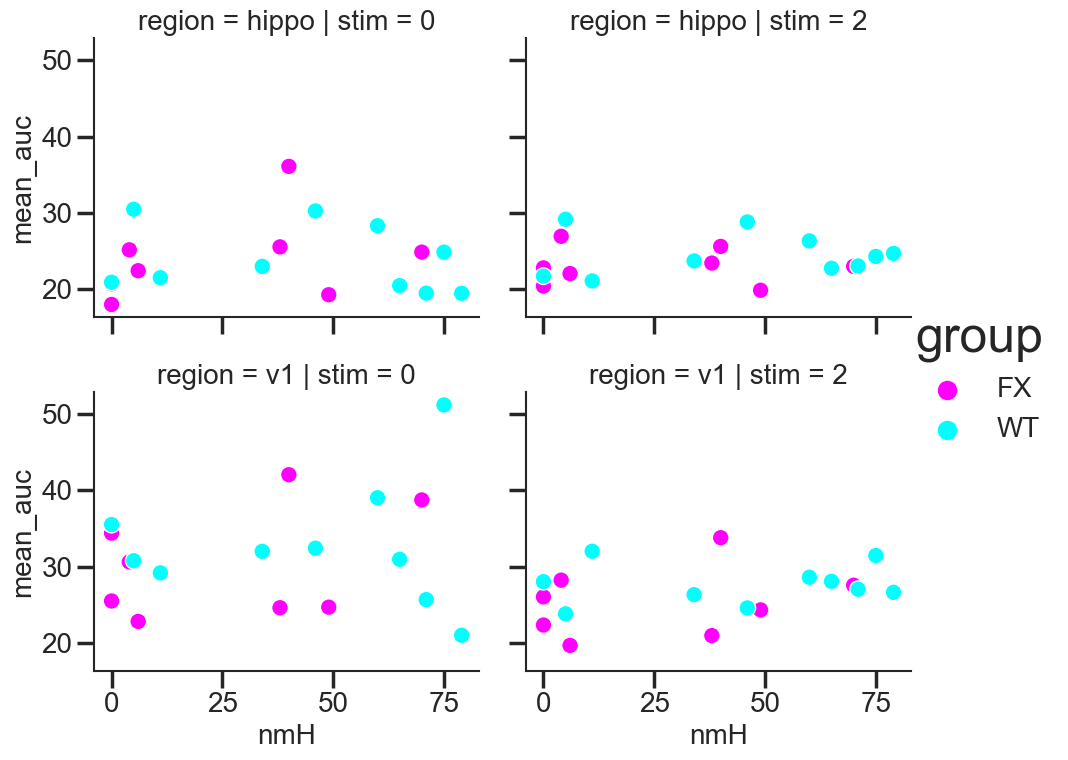

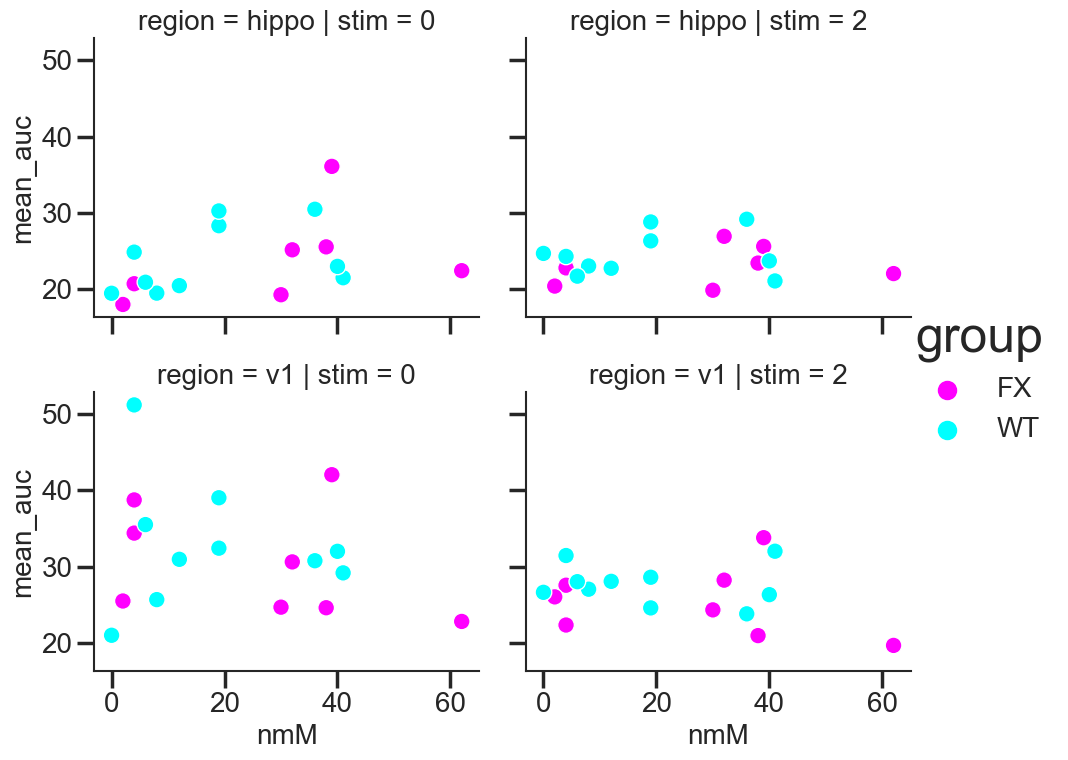

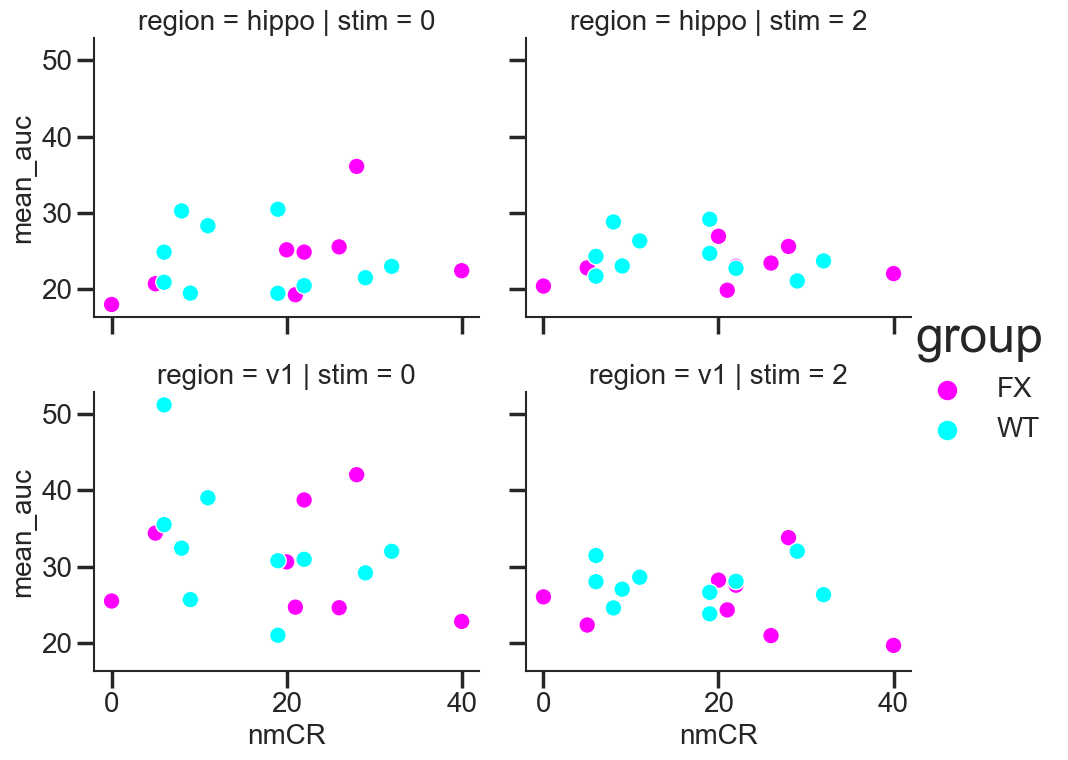

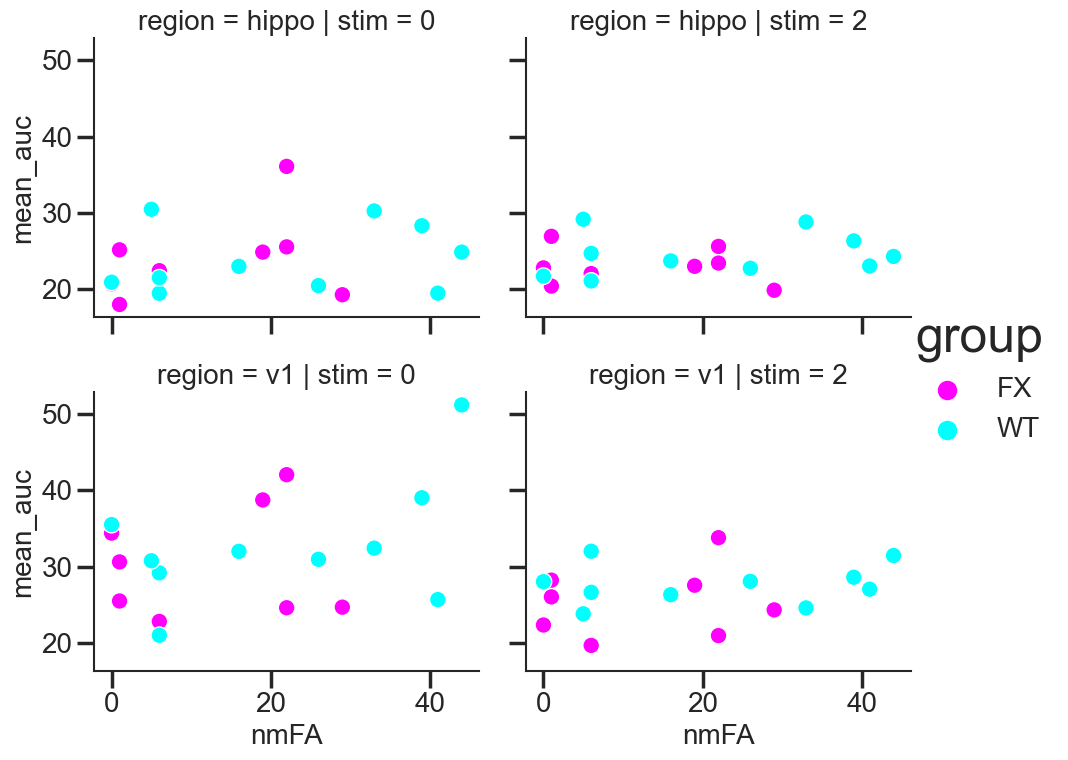

~~~~~~~~~~ 0 ~~~~~~~~~~


ValueError: Could not interpret value `behav` for parameter `col`

In [18]:
y_choice = 'mean_auc' # mean_auc & median_auc

for x_choice in ["nmH", "nmM", "nmCR", "nmFA"]:
    sns.relplot(data=mean_theta, x=x_choice, y=y_choice, hue='group', col='stim', row='region', 
                palette={'WT':'cyan', 'FX':'magenta'}, height=4, aspect=1.2)
    plt.show()

for d,dd in mean_theta.groupby('stim'):
    print(f"~~~~~~~~~~ {d} ~~~~~~~~~~")
    sns.relplot(data=dd, x='nmH', y='mean_auc', 
                col='behav', row='region', 
                hue='group', palette={'WT':'cyan', 'FX':'magenta'}, 
                height=3, facet_kws={'sharey': True, 'sharex': False})
    plt.suptitle(d)
    plt.show()

# Plot the results (LFP and behavior)

In [14]:
display(all_trial_lfp.head(2))
display(behavior.head(2))

,et,cc,group,trial,lfp_data,stim_id
0,CC067431_HP2,CC067431,FX,0,"[[125.99329, 120.050354, 137.86186, 156.05075,...",0
1,CC067431_HP2,CC067431,FX,1,"[[-57.64133, -62.18796, -66.814, -47.926105, -...",2


,trial,lick_idx,lick_time,true_tr,et,cc,stim_id,behav
0,1,0,-1.899998,3,CC067431_HP2,CC067431,Go+,M
1,1,1,-1.509998,3,CC067431_HP2,CC067431,Go+,M


## LFP traces and licks (all mice all trials)

In [15]:
v1_ch = 260
hpc_ch = 110

show_plots = False

lfp_behav, i = [], 0
# plot the single trial veps with the licks overlaid
for d,dd in all_trial_lfp.groupby(['et','trial']):
    #gets the v1 lfp trace for the et/trial pairing
    tr_stim = dd.stim_id.unique()[0]
    plt_stim = 'Go+' if tr_stim=='0' else ('Go-' if tr_stim=='1' else 'No-Go')
    tr_lfp = dd.lfp_data.values[0]
    v1_lfp = tr_lfp[v1_ch,:]
    hpc_lfp = tr_lfp[hpc_ch,:]
    #trims the behavior df to the et/trial pairing
    tmp0 = behavior[(behavior.et==d[0])&(behavior.true_tr==d[1])&(behavior.lick_time>-0.5)&(behavior.lick_time<2.5)]
    tmp = tmp0['lick_time'].values+0.5 #lick times now zeroed to start of recording
    num_licks = len([x for x in tmp if (x>1.0)&(x<1.7)]) #counting the number of licks within the delay period
    tr_beh = tmp0.behav.unique()[0] if tmp0.size else ('CR' if plt_stim=='No-Go' else 'M') #OR else 'nolick'
    #save to new df --- columns = trial, et, group, stim_id, v1_lfp, hpc_lfp, num_licks, behav
    lfp_behav.append([d[1], d[0], dd.group.unique()[0], plt_stim, v1_lfp.astype('float16'), hpc_lfp.astype('float16'), num_licks, tr_beh])
    #plot the lfp traces and the licks overlaid
    if show_plots==False:
        if i%500 == 0:
            print(f"Done with {i} out of {all_trial_lfp.et.nunique()*all_trial_lfp.trial.nunique()}") #loading bar if not plotting LFPs and lick rasters
        i+=1
    else:
        x_times = np.linspace(0,3,v1_lfp.shape[0])
        plt_color = 'cyan' if dd.group.unique()[0]=='WT' else 'magenta'
        fig,ax = plt.subplots(1,2, sharex=True, figsize=(15,2.5))
        ax[0].axvspan(0.5,0.7, color='grey', alpha=0.2)
        ax[1].axvspan(0.5,0.7, color='grey', alpha=0.2)
        if plt_stim=='Go+':
            ax[0].axvline(1.7, color='royalblue')
            ax[1].axvline(1.7, color='royalblue')
        elif plt_stim=='Go-':
            ax[0].axvline(1.7, color='grey')
            ax[1].axvline(1.7, color='grey')
        else:
            ax[0].axvline(1.7, color='grey', ls='--')
            ax[1].axvline(1.7, color='grey', ls='--')
        ax[0].plot(x_times, scnd.gaussian_filter1d(v1_lfp, sigma=20), color=plt_color) #plot gaussian filtered V1 vep
        ax[0].scatter(x=tmp, y=[-500]*len(tmp), marker='|', c='black', s=70) #plot licks
        ax[1].plot(x_times, scnd.gaussian_filter1d(hpc_lfp, sigma=20), color=plt_color) #plot gaussian filtered V1 vep
        ax[1].scatter(x=tmp, y=[-800]*len(tmp), marker='|', c='black', s=70) #plot licks
        ax[0].set_xlabel('Time (s)')
        ax[1].set_xlabel('Time (s)')
        ax[0].set_ylabel('V1')
        ax[0].set_ylim([-600,600])
        ax[1].set_ylim([-900,900])
        ax[0].set_title(f"{d[0]} ~~ Trial {d[1]} ~~ {plt_stim} ~~ {tr_beh}")
        ax[1].set_ylabel('HPC')
        sns.despine()
        plt.show()
lfp_behav = pd.DataFrame(lfp_behav, columns=['trial','et','group','stim_id','v1_lfp','hpc_lfp','num_licks','behav'])

Done with 0 out of 2700
Done with 500 out of 2700
Done with 1000 out of 2700
Done with 1500 out of 2700
Done with 2000 out of 2700
Done with 2500 out of 2700


## LFP oscillation FFT and behavior

In [16]:
def get_lfp_fft(lfp_arr, sr=2500, limit_time=False):
    if limit_time:
        time_cut_arr = lfp_arr[int(sr*limit_time[0]):int(sr*limit_time[1])] #limits the LFP trace to [0.5, 1.7] and quantify power on that time
    else:
        time_cut_arr = lfp_arr
    freq = np.arange(time_cut_arr.shape[0]) / time_cut_arr.shape[0] * sr #sr of the lfp traces
    freq = freq[:freq.shape[0]//2]
    f = np.fft.fft(time_cut_arr)
    magnitude_spectrum = (np.abs(f)[:freq.shape[0]])
    return freq, magnitude_spectrum

In [17]:
lfp_fft = []
for lfp,df in lfp_behav.groupby(['et','trial']):
# for lfp,df in lfp_behav[lfp_behav.trial<100].groupby(['et','trial']): #limit the # of trials to account for loss of motivation in later ones? ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    fft_freq, fft_amp = get_lfp_fft(df.v1_lfp.values[0], limit_time=[0.5,1.8])
    bands = [[2,4],[4,8],[8,12],[12,30],[30,70]]
    auc_val,band_val,mean_ls,peak_val = [],[],[],[]
    for ran in bands:
        lower = fft_freq.searchsorted(ran[0], 'left')
        upper = fft_freq.searchsorted(ran[1], 'right') -1
        val = auc(fft_freq[lower:upper],fft_amp[lower:upper])
        mean_val = np.mean(fft_amp[lower:upper])
        peak = np.max(fft_amp[lower:upper])
        auc_val.append(val/100000) #scale factor for the auc values
        mean_ls.append(mean_val/10000)
        peak_val.append(peak/10000)
        band_val.append(str(ran))
    lfp_fft.append(pd.DataFrame({'trial':lfp[1], 'band':band_val, 'mean_val':mean_ls, 'peak_val':peak_val, 'auc':auc_val, 'et':lfp[0], 'region':'V1',
                                 'group':df.group.unique()[0], 'stim_id':df.stim_id.unique()[0], 'num_licks':df.num_licks.unique()[0], 'behav':df.behav.unique()[0]}))

    #repeat above for the HPC channel
    fft_freq, fft_amp = get_lfp_fft(df.hpc_lfp.values[0], limit_time=[0.5,1.8])
    auc_val,band_val,mean_ls,peak_val = [],[],[],[]
    for ran in bands:
        lower = fft_freq.searchsorted(ran[0], 'left')
        upper = fft_freq.searchsorted(ran[1], 'right') -1
        val = auc(fft_freq[lower:upper],fft_amp[lower:upper])
        mean_val = np.mean(fft_amp[lower:upper])
        peak = np.max(fft_amp[lower:upper])
        auc_val.append(val/100000)
        mean_ls.append(mean_val/10000)
        peak_val.append(peak/10000)
        band_val.append(str(ran))
    lfp_fft.append(pd.DataFrame({'trial':lfp[1], 'band':band_val, 'mean_val':mean_ls, 'peak_val':peak_val, 'auc':auc_val, 'et':lfp[0],  'region':'HPC',
                                 'group':df.group.unique()[0], 'stim_id':df.stim_id.unique()[0], 'num_licks':df.num_licks.unique()[0], 'behav':df.behav.unique()[0]}))
lfp_fft = pd.concat(lfp_fft)
# replace instances of H2 & M2 with H & M
lfp_fft['behav'] = lfp_fft['behav'].replace(['H2','M2'], ['H','M'])
lfp_fft.head()

,trial,band,mean_val,peak_val,auc,et,region,group,stim_id,num_licks,behav
0,0,"[2, 4]",9.128546,11.356609,0.702196,CC067431_HP2,V1,FX,Go+,0,M
1,0,"[4, 8]",4.377809,7.915976,1.034116,CC067431_HP2,V1,FX,Go+,0,M
2,0,"[8, 12]",5.433314,8.382743,1.208840,CC067431_HP2,V1,FX,Go+,0,M
3,0,"[12, 30]",1.525255,3.861295,2.500182,CC067431_HP2,V1,FX,Go+,0,M
4,0,"[30, 70]",1.378982,3.535084,5.428608,CC067431_HP2,V1,FX,Go+,0,M


## Plotting results of all trials
N = #trials

In [26]:
do_plot=False
feature_choice = 'peak_val'

for d,dd in lfp_fft.groupby(['stim_id','region']):
    if do_plot:
        fig,ax = plt.subplots(1,2, sharex=True, figsize=(15,3.5))
    plt_order = ['CR','FA'] if d[0]=='No-Go' else ['H','M']
    print("2-sided KS test comparing the distributions of WT & FX")
    for i,b in enumerate(plt_order):
        plt_df = dd[(dd.band=="[4, 8]")&(dd.behav==b)]
        x,y = plt_df[plt_df.group=='WT'][feature_choice].values, plt_df[plt_df.group=='FX'][feature_choice].values
        res = sstat.ks_2samp(x,y)
        plt_stats = "***" if res.pvalue < 0.001 else ("**" if res.pvalue<0.01 else ("*" if res.pvalue <0.05 else "ns"))
        if do_plot:
            sns.histplot(data=plt_df, x=feature_choice, binwidth=1, 
                         hue='group', hue_order=['WT','FX'], 
                         stat='density', common_norm=False, 
                         kde=True, legend=False, ax=ax[i])
            ax[i].set_title(f"{d} ~~ {b}")
            if feature_choice == 'peak_val':
                ax[i].text(x=25, y=0.06, s=plt_stats)
            else:
                ax[i].text(x=6, y=0.2, s=plt_stats)
        print(f"{d} {b} -- N: WT={len(x)}, F={len(y)} -- p={res.pvalue} --", plt_stats)
    if do_plot:
        sns.despine()
        # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\allTrial_AUChistogram_{d}.pdf", transparent=True)
        plt.show()

2-sided KS test comparing the distributions of WT & FX
('Go+', 'HPC') H -- N: WT=446, F=207 -- p=2.512431891549712e-07 -- ***
('Go+', 'HPC') M -- N: WT=354, F=433 -- p=0.002708932604339776 -- **
2-sided KS test comparing the distributions of WT & FX
('Go+', 'V1') H -- N: WT=446, F=207 -- p=8.742182956338392e-18 -- ***
('Go+', 'V1') M -- N: WT=354, F=433 -- p=9.973219726020934e-16 -- ***
2-sided KS test comparing the distributions of WT & FX
('Go-', 'HPC') H -- N: WT=108, F=57 -- p=0.028881429956729134 -- *
('Go-', 'HPC') M -- N: WT=92, F=103 -- p=0.01842613951298935 -- *
2-sided KS test comparing the distributions of WT & FX
('Go-', 'V1') H -- N: WT=108, F=57 -- p=2.098690014475853e-06 -- ***
('Go-', 'V1') M -- N: WT=92, F=103 -- p=8.143518864606875e-08 -- ***
2-sided KS test comparing the distributions of WT & FX
('No-Go', 'HPC') CR -- N: WT=284, F=300 -- p=0.0010616442162814928 -- **
('No-Go', 'HPC') FA -- N: WT=216, F=100 -- p=0.02114348295179473 -- *
2-sided KS test comparing the d

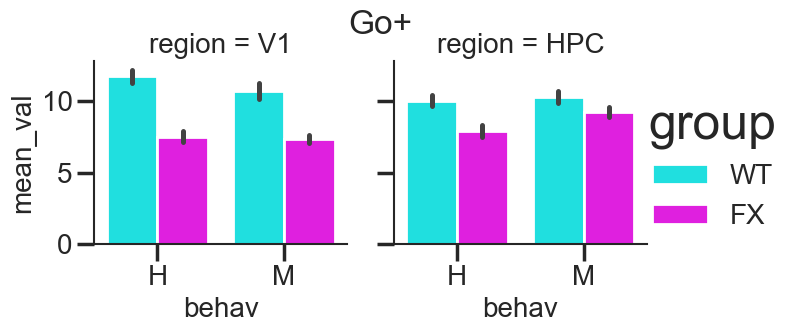

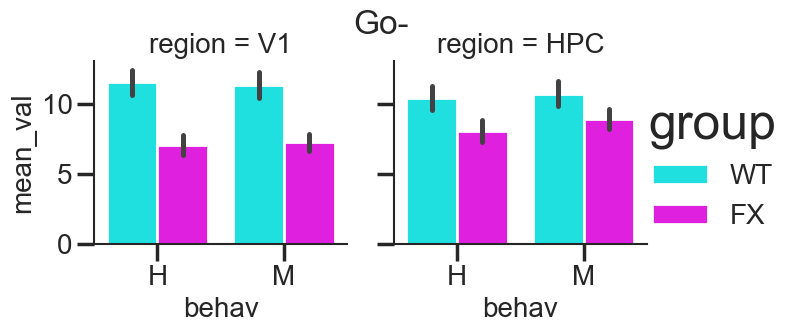

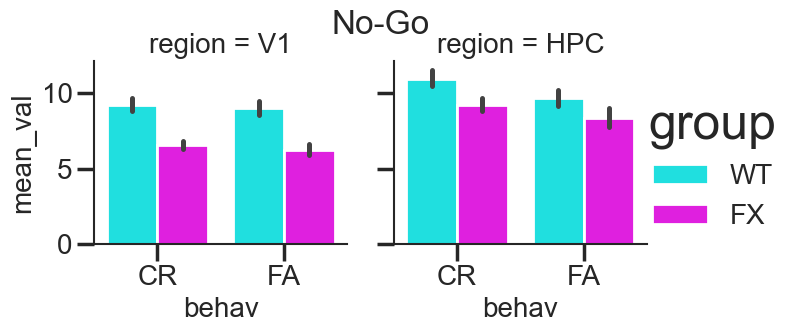

In [27]:
for d,dd in lfp_fft.groupby('stim_id'):
    aver_df = dd[dd.band=="[4, 8]"]
    plt_order = ['CR','FA'] if d=='No-Go' else ['H','M']
    sns.catplot(data=aver_df, x='behav', y='mean_val', kind='bar', col='region', order=plt_order,
                hue='group', hue_order=['WT','FX'], palette={'WT':'cyan','FX':'magenta'}, 
                height=3.5, aspect=1)
    # plt.ylim([0,6.5])
    plt.suptitle(d)
    sns.despine()
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\allTrial_AUCbarplot_{d}.pdf", transparent=True)
    plt.show()

In [28]:
feature_choice = 'peak_val'

#Mann Whitney U to compare pairwise within each band for each region
print('~~~~~~~~~~~~ Comparing WT/FX for each region/stim/behav ~~~~~~~~~~~~')
for d,dd in lfp_fft[lfp_fft.band=="[4, 8]"].groupby(['region','stim_id','behav']):
    x,y = dd[dd.group=='WT'][feature_choice].values, dd[dd.group=='FX'][feature_choice].values
    U,pval = sstat.mannwhitneyu(x,y)
    print(f"{d} -- N (#trials, all mice): WT={len(x)}, FX={len(y)} -- pvals: {pval} -- ",
          '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns')))

#Mann Whitney U to compare pairwise within each group for each region
print('\n~~~~~~~~~~~~ Comparing behav for each region/stim/group ~~~~~~~~~~~~')
for d,dd in lfp_fft[lfp_fft.band=="[4, 8]"].groupby(['region','stim_id','group']):
    beh = dd.behav.unique()
    x,y = dd[dd.behav==beh[0]][feature_choice].values, dd[dd.behav==beh[1]][feature_choice].values
    U,pval = sstat.mannwhitneyu(x,y)
    print(f"{d} -- N (#trials, all mice): WT={len(x)}, FX={len(y)} -- pvals: {pval} -- ",
          '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns')))

~~~~~~~~~~~~ Comparing WT/FX for each region/stim/behav ~~~~~~~~~~~~
('HPC', 'Go+', 'H') -- N (#trials, all mice): WT=446, FX=207 -- pvals: 1.2481763049705655e-09 --  ***
('HPC', 'Go+', 'M') -- N (#trials, all mice): WT=354, FX=433 -- pvals: 0.0004756338634495353 --  ***
('HPC', 'Go-', 'H') -- N (#trials, all mice): WT=108, FX=57 -- pvals: 0.0024652904065049328 --  **
('HPC', 'Go-', 'M') -- N (#trials, all mice): WT=92, FX=103 -- pvals: 0.004914638373048558 --  **
('HPC', 'No-Go', 'CR') -- N (#trials, all mice): WT=284, FX=300 -- pvals: 1.4781705590148923e-05 --  ***
('HPC', 'No-Go', 'FA') -- N (#trials, all mice): WT=216, FX=100 -- pvals: 0.007626071283716478 --  **
('V1', 'Go+', 'H') -- N (#trials, all mice): WT=446, FX=207 -- pvals: 6.981631400804677e-23 --  ***
('V1', 'Go+', 'M') -- N (#trials, all mice): WT=354, FX=433 -- pvals: 7.064755724306309e-17 --  ***
('V1', 'Go-', 'H') -- N (#trials, all mice): WT=108, FX=57 -- pvals: 6.443962798138877e-07 --  ***
('V1', 'Go-', 'M') -- N (

# Remake df, grouped by mouse
This is for each mouse, meaning my N = #mice NOT #trials like above

In [18]:
trial_lims = [0,150]

lfp_avg_fft = []
for d,dd in lfp_fft[(lfp_fft.trial>=trial_lims[0])&(lfp_fft.trial<=trial_lims[1])].groupby(['et','region','band','group','stim_id','behav']):
    lfp_avg_fft.append(pd.DataFrame({'band':d[2], 'auc':dd.auc.mean(), 'peak_val':dd.peak_val.mean(), 'mean_val':dd.mean_val.mean(), 
                                     'et':d[0], 'region':d[1], 'group':d[3], 'stim_id':d[4], 'behav':d[5]}, index=[0]))
lfp_avg_fft = pd.concat(lfp_avg_fft, ignore_index=True)
lfp_avg_fft.head()

,band,auc,peak_val,mean_val,et,region,group,stim_id,behav
0,"[12, 30]",6.698265,9.087649,3.984702,CC067431_HP2,HPC,FX,Go+,H
1,"[12, 30]",6.722032,9.175949,3.992343,CC067431_HP2,HPC,FX,Go+,M
2,"[12, 30]",7.415590,8.418918,4.299431,CC067431_HP2,HPC,FX,Go-,H
3,"[12, 30]",6.969369,9.627335,4.124622,CC067431_HP2,HPC,FX,Go-,M
4,"[12, 30]",6.985528,9.522345,4.136918,CC067431_HP2,HPC,FX,No-Go,CR


# other ideas...

In [19]:
# remove mice that are inactive (less than n HIT trials)
active_ets = []
for d,dd in lfp_fft[lfp_fft.band=='[4, 8]'].groupby('et'):
    num_Hits = dd.groupby('behav').trial.nunique().to_dict()['H'] if 'H' in dd.groupby('behav').trial.nunique().to_dict() else 0
    if num_Hits>=5:
        active_ets.append(d)
active_ets.remove("CC067489_HP2") #removing an outlier found from the plots below
print(active_ets)

['CC067431_HP2', 'CC067432_HP3', 'CC067432_HP4', 'CC067489_HP3', 'CC082255_HP0', 'CC082255_HP3', 'CC082257_HP3', 'CC082260_HP2', 'CC082260_HP3', 'CC082260_HP4', 'CC082263_HP1', 'CC082263_HP2', 'CC084621_HP1', 'CC084621_HP2']


# Previous plot - histogram

2-sided KS test comparing the distributions of WT & FX
Go+ ('HPC', 'H') -- N: WT=8, F=6 -- p=0.4602064602064602 -- ns
Go+ ('HPC', 'M') -- N: WT=8, F=6 -- p=0.6373626373626372 -- ns
Go+ ('V1', 'H') -- N: WT=8, F=6 -- p=0.022644022644022637 -- *
Go+ ('V1', 'M') -- N: WT=8, F=6 -- p=0.19247419247419248 -- ns


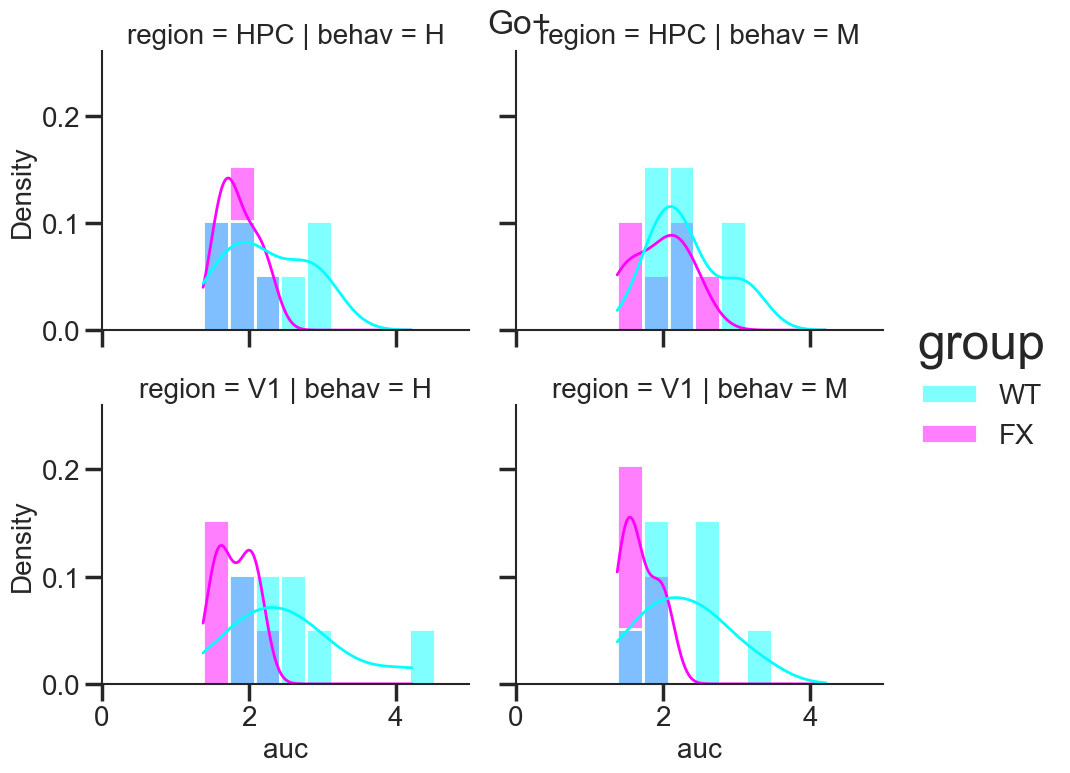

2-sided KS test comparing the distributions of WT & FX
Go- ('HPC', 'H') -- N: WT=8, F=6 -- p=0.7838827838827839 -- ns
Go- ('HPC', 'M') -- N: WT=8, F=6 -- p=0.30169830169830175 -- ns
Go- ('V1', 'H') -- N: WT=8, F=6 -- p=0.13919413919413917 -- ns
Go- ('V1', 'M') -- N: WT=8, F=6 -- p=0.13919413919413917 -- ns


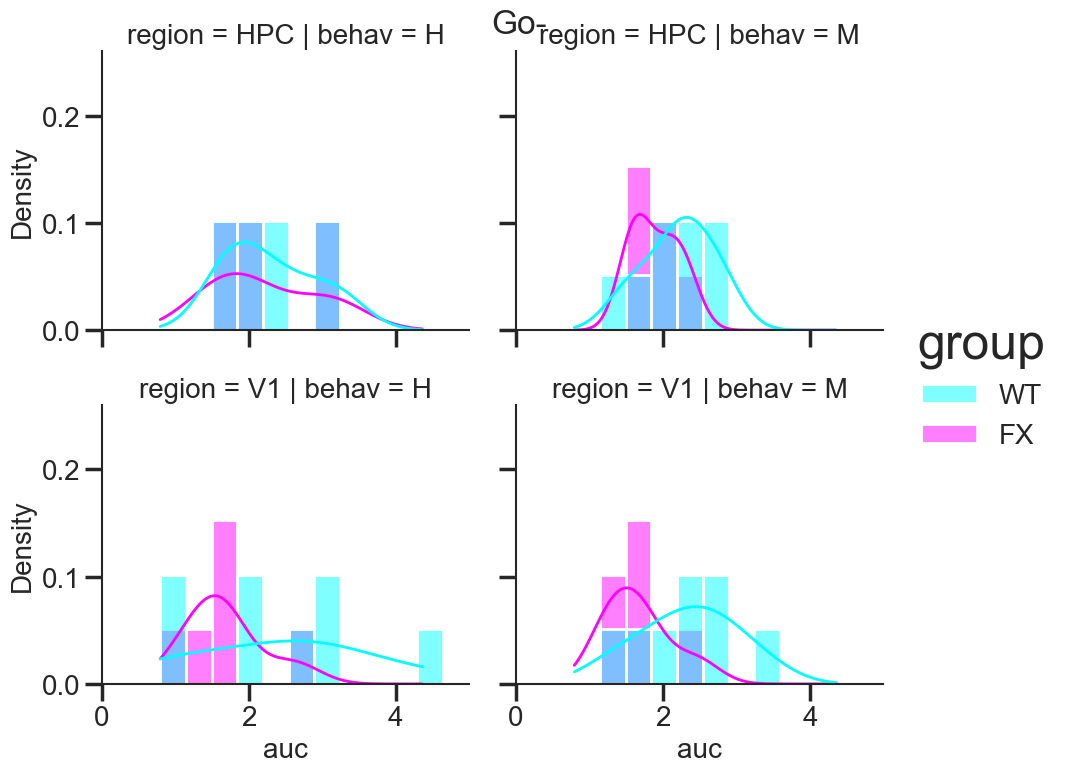

2-sided KS test comparing the distributions of WT & FX
No-Go ('HPC', 'CR') -- N: WT=8, F=6 -- p=0.30169830169830175 -- ns
No-Go ('HPC', 'FA') -- N: WT=8, F=6 -- p=0.30169830169830175 -- ns
No-Go ('V1', 'CR') -- N: WT=8, F=6 -- p=0.13919413919413917 -- ns
No-Go ('V1', 'FA') -- N: WT=8, F=6 -- p=0.09257409257409258 -- ns


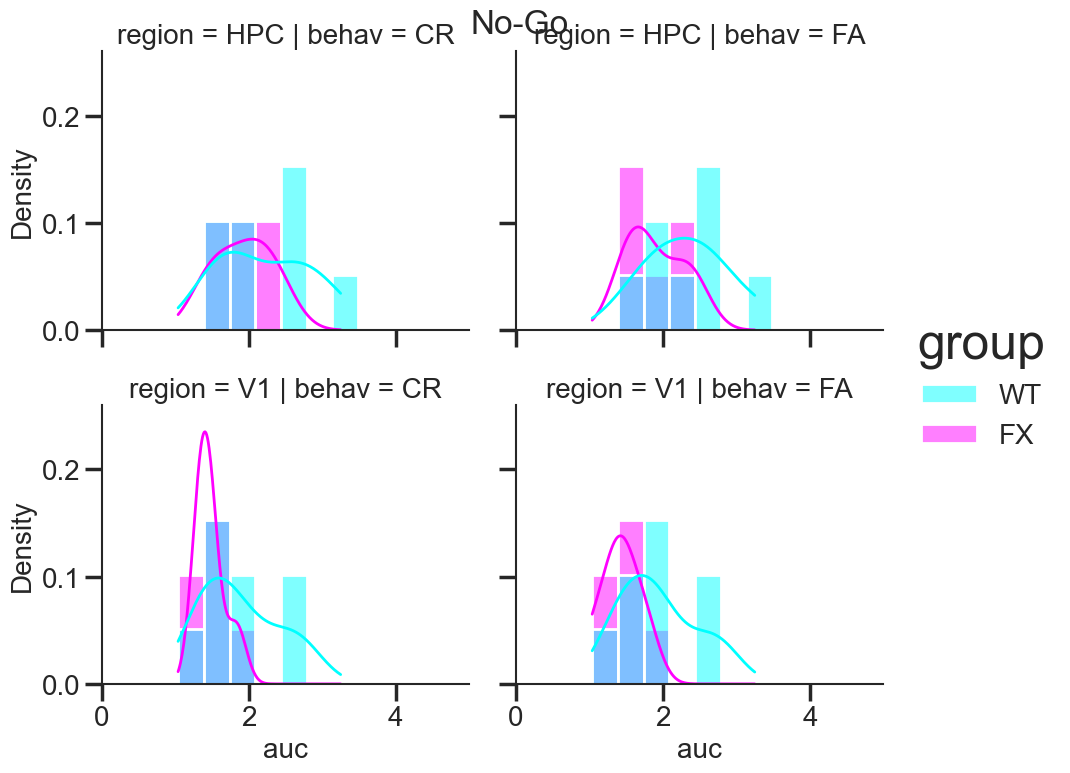

In [30]:
feature_choice = 'auc' #'auc', 'mean_val', 'peak_val'

for d,dd in lfp_avg_fft[lfp_avg_fft.et.isin(active_ets)].groupby('stim_id'):
    plt_data = dd[dd.band=='[4, 8]']
    sns.displot(data=plt_data, x=feature_choice, hue='group', hue_order=['WT','FX'],
                kde=True, rug=False, stat='density', binwidth=0.35, col='behav', row='region', height=4, aspect=1.2)
    plt.ylim([0,0.26])
    plt.xlim([0,5])
    plt.suptitle(d)
    print("2-sided KS test comparing the distributions of WT & FX")
    for e,ee in plt_data.groupby(['region','behav']):
        x,y = ee[ee.group=='WT'][feature_choice].values, ee[ee.group=='FX'][feature_choice].values # N = #mice bc behavior outcome is separate (ie Go+ has Hit and Miss)
        res = sstat.ks_2samp(x,y)
        plt_stats = "***" if res.pvalue < 0.001 else ("**" if res.pvalue<0.01 else ("*" if res.pvalue <0.05 else "ns"))
        print(f"{d} {e} -- N: WT={len(x)}, F={len(y)} -- p={res.pvalue} --", plt_stats)
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\allTrial_AUChistogram_{d}.pdf", transparent=True)
    plt.show()

2-sided KS test comparing the distributions of behavior within group
Go+ ('HPC', 'FX') -- N: WT=6, F=6 -- p=0.9307359307359307 -- ns
Go+ ('HPC', 'WT') -- N: WT=8, F=8 -- p=0.98010878010878 -- ns
Go+ ('V1', 'FX') -- N: WT=6, F=6 -- p=0.474025974025974 -- ns
Go+ ('V1', 'WT') -- N: WT=8, F=8 -- p=0.98010878010878 -- ns


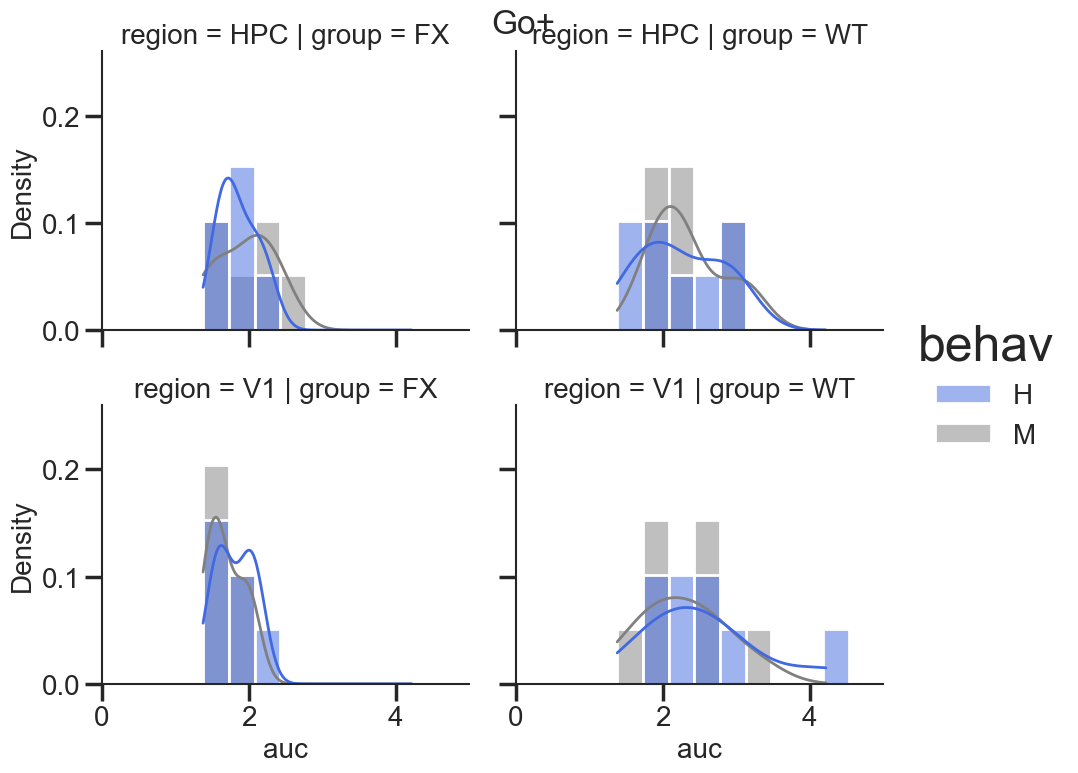

2-sided KS test comparing the distributions of behavior within group
Go- ('HPC', 'FX') -- N: WT=6, F=6 -- p=0.9307359307359307 -- ns
Go- ('HPC', 'WT') -- N: WT=8, F=8 -- p=0.98010878010878 -- ns
Go- ('V1', 'FX') -- N: WT=6, F=6 -- p=0.9999999999999998 -- ns
Go- ('V1', 'WT') -- N: WT=8, F=8 -- p=0.98010878010878 -- ns


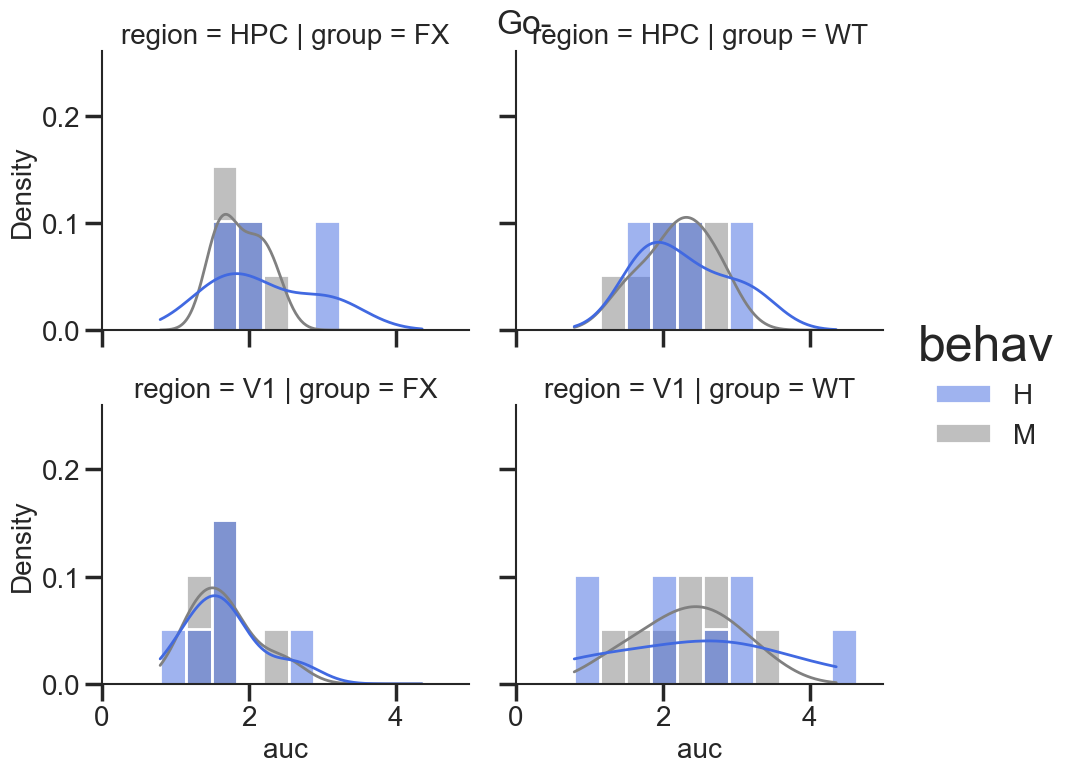

2-sided KS test comparing the distributions of behavior within group
No-Go ('HPC', 'FX') -- N: WT=6, F=6 -- p=0.9999999999999998 -- ns
No-Go ('HPC', 'WT') -- N: WT=8, F=8 -- p=0.6601398601398599 -- ns
No-Go ('V1', 'FX') -- N: WT=6, F=6 -- p=0.9307359307359307 -- ns
No-Go ('V1', 'WT') -- N: WT=8, F=8 -- p=1.0 -- ns


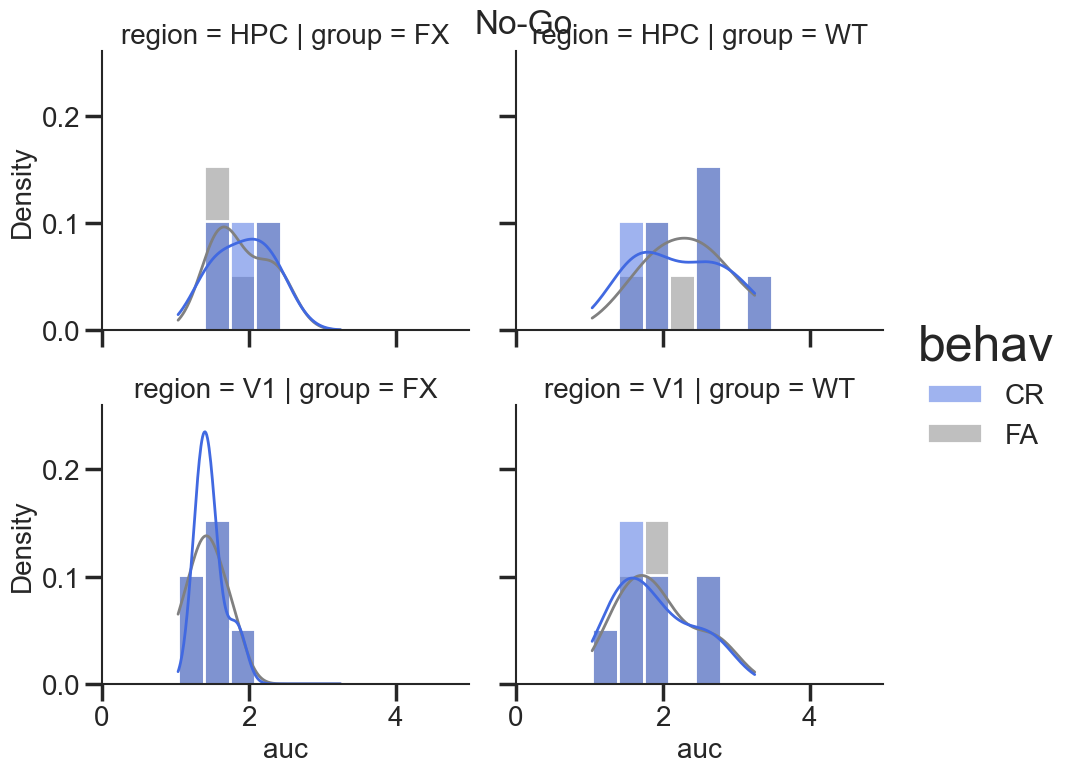

In [29]:
feature_choice = 'auc' #'auc', 'mean_val', 'peak_val'

for d,dd in lfp_avg_fft[lfp_avg_fft.et.isin(active_ets)].groupby('stim_id'):
    plt_data = dd[dd.band=='[4, 8]']
    sns.displot(data=plt_data, x=feature_choice, hue='behav', palette={'H':'royalblue','M':'grey','CR':'royalblue','FA':'grey'},
                kde=True, rug=False, stat='density', binwidth=0.35, col='group', row='region', height=4, aspect=1.2)
    plt.ylim([0,0.26])
    plt.xlim([0,5])
    plt.suptitle(d)
    print("2-sided KS test comparing the distributions of behavior within group")
    for e,ee in plt_data.groupby(['region','group']):
        if (d=='Go+')|(d=='Go-'):
            x,y = ee[ee.behav=='H'][feature_choice].values, ee[ee.behav=='M'][feature_choice].values # N = #mice bc behavior outcome is separate (ie Go+ has Hit and Miss)
        else:
            x,y = ee[ee.behav=='CR'][feature_choice].values, ee[ee.behav=='FA'][feature_choice].values
        res = sstat.ks_2samp(x,y)
        plt_stats = "***" if res.pvalue < 0.001 else ("**" if res.pvalue<0.01 else ("*" if res.pvalue <0.05 else "ns"))
        print(f"{d} {e} -- N: WT={len(x)}, F={len(y)} -- p={res.pvalue} --", plt_stats)
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\allTrial_AUChistogram_{d}.pdf", transparent=True)
    plt.show()

# ! Previous plot - scatter (trial # and AUC, split by behavior)

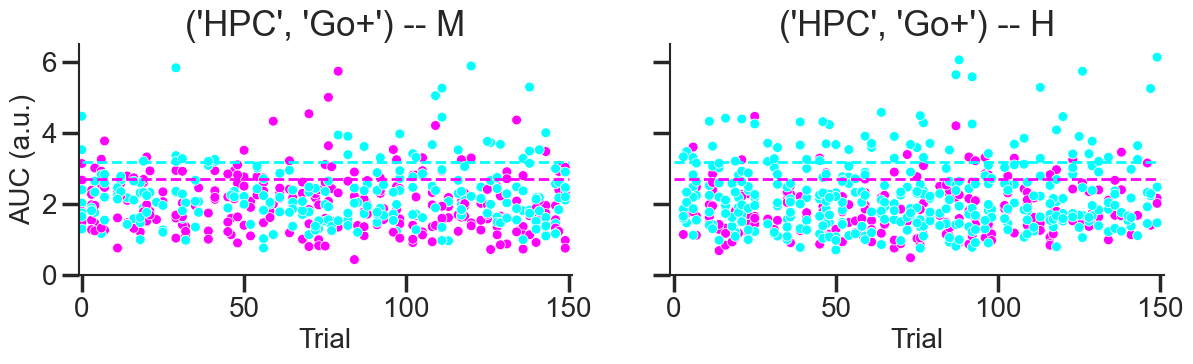

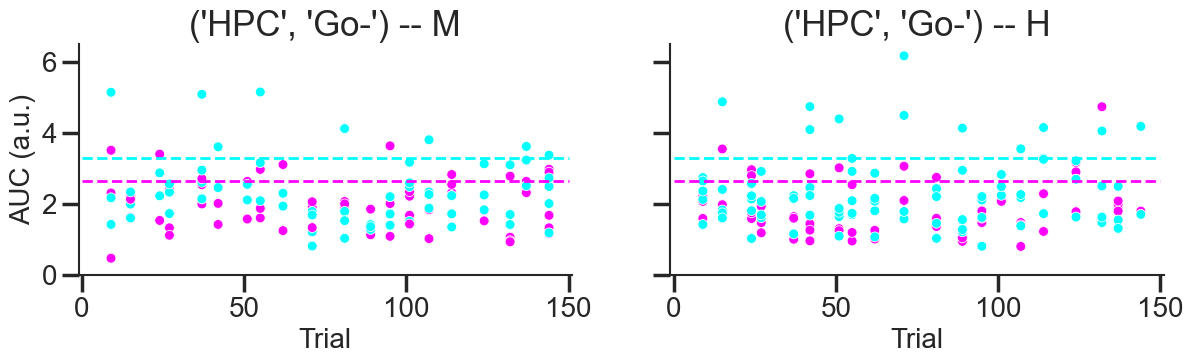

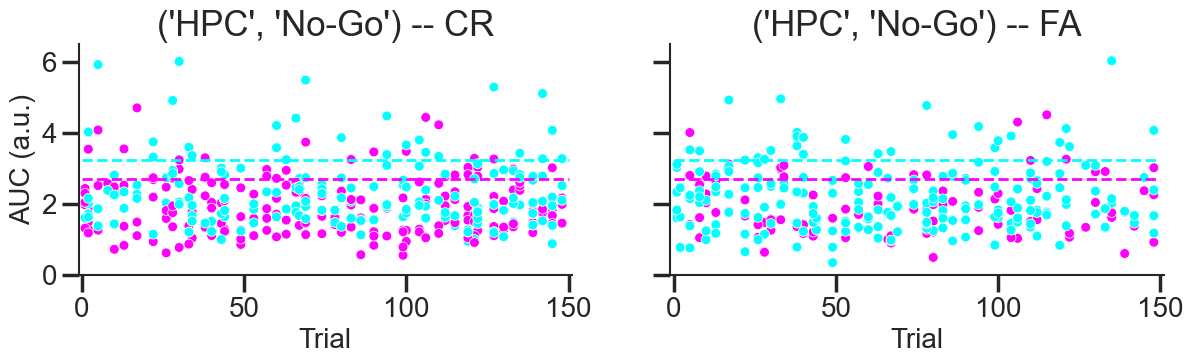

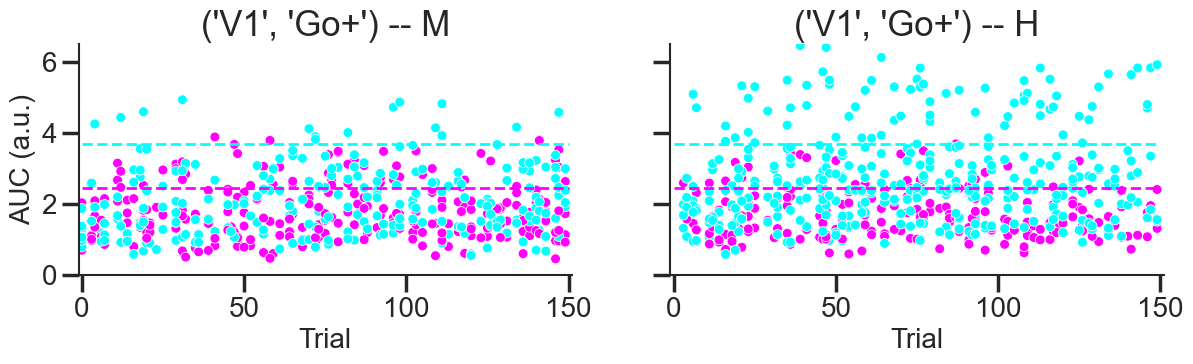

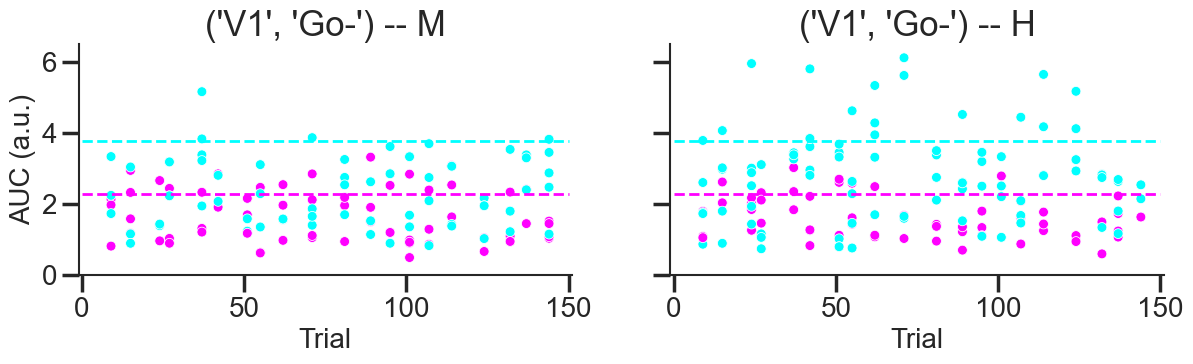

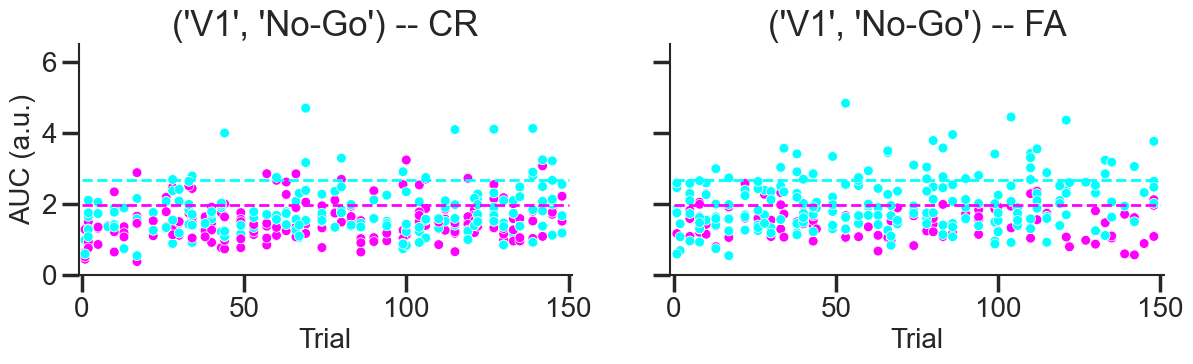

In [33]:
feature_choice = 'auc' #'auc', 'mean_val', 'peak_val'

for d,dd in lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et.isin(active_ets))].groupby(['region','stim_id']):
    behav_ls = dd.behav.unique()
    fig,ax=plt.subplots(1,2,figsize=(14,3), sharey=True)
    wt_beh_thresh = dd[dd.group=='WT'][feature_choice].mean() + dd[dd.group=='WT'][feature_choice].std() #mean + 1std to use as the threshold for WT
    fx_beh_thresh = dd[dd.group=='FX'][feature_choice].mean() + dd[dd.group=='FX'][feature_choice].std() #mean + 1std to use as the threshold for FX
    ax[0].hlines(y=[wt_beh_thresh, fx_beh_thresh], xmin=0, xmax=150, colors=['cyan','magenta'], ls='--')
    ax[1].hlines(y=[wt_beh_thresh, fx_beh_thresh], xmin=0, xmax=150, colors=['cyan','magenta'], ls='--')

    sns.scatterplot(data=dd[dd.behav==behav_ls[0]], x='trial', y=feature_choice, s=50, hue='group', palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[0], legend=False)
    sns.scatterplot(data=dd[dd.behav==behav_ls[1]], x='trial', y=feature_choice, s=50, hue='group', palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[1], legend=False)
    ax[0].set_title(f'{d} -- {behav_ls[0]}')
    ax[1].set_title(f'{d} -- {behav_ls[1]}')
    ax[0].set_xlim([-1,151])
    ax[1].set_xlim([-1,151])
    ax[0].set_ylim([0,6.5])
    ax[1].set_ylim([0,6.5])
    ax[0].set_xlabel('Trial')
    ax[0].set_ylabel('AUC (a.u.)')
    ax[1].set_xlabel('Trial')
    sns.despine()
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\allTrial_AUCscatterplot_{d[0]}_{d[1]}_v2.pdf", transparent=True)
    plt.show()

In [ ]:
# make the same threshold for each stimulus group, not each stimulus/behavior group
feature_choice = 'auc' #'auc', 'mean_val', 'peak_val'
group_thresh = True

for d,dd in lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et.isin(active_ets))].groupby(['region','stim_id']):
    if d[1] == 'No-Go':
        behav_ls = ['CR', 'FA']
    else:
        behav_ls = ['H', 'M']
    fig,ax=plt.subplots(2,2,figsize=(14,6), sharey=True)
    ax=ax.flatten()
    if group_thresh:
        wt_beh_thresh = dd[dd.group=='WT'][feature_choice].mean() + dd[dd.group=='WT'][feature_choice].std() #mean + 1std to use as the threshold for WT
        fx_beh_thresh = dd[dd.group=='FX'][feature_choice].mean() + dd[dd.group=='FX'][feature_choice].std() #mean + 1std to use as the threshold for FX
        # ax[0].hlines(y=[wt_beh_thresh,fx_beh_thresh], xmin=0, xmax=150, colors=['cyan','magenta'], ls='--')
        # ax[1].hlines(y=[wt_beh_thresh,fx_beh_thresh], xmin=0, xmax=150, colors=['cyan','magenta'], ls='--')
        ax[0].hlines(y=[wt_beh_thresh], xmin=0, xmax=150, colors=['cyan'], ls='--')
        ax[1].hlines(y=[wt_beh_thresh], xmin=0, xmax=150, colors=['cyan'], ls='--')
        ax[2].hlines(y=[fx_beh_thresh], xmin=0, xmax=150, colors=['magenta'], ls='--')
        ax[3].hlines(y=[fx_beh_thresh], xmin=0, xmax=150, colors=['magenta'], ls='--')
    else:
        beh_thresh = dd[feature_choice].mean() + (1.5*dd[feature_choice].std()) #mean + 1.5std to use as the threshold for FX
        ax[0].axhline(y=beh_thresh, color='grey', ls='--')
        ax[1].axhline(y=beh_thresh, color='grey', ls='--')
    # sns.scatterplot(data=dd[dd.behav==behav_ls[0]], x='trial', y=feature_choice, s=50, hue='group', palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[0], legend=False)
    # sns.scatterplot(data=dd[dd.behav==behav_ls[1]], x='trial', y=feature_choice, s=50, hue='group', palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[1], legend=False)
    sns.lineplot(data=dd[(dd.behav==behav_ls[0])&(dd.group=='WT')], x='trial', y=feature_choice, hue='et', palette='tab10', ax=ax[0], legend=False)
    sns.lineplot(data=dd[(dd.behav==behav_ls[1])&(dd.group=='WT')], x='trial', y=feature_choice, hue='et', palette='tab10', ax=ax[1], legend=False)
    sns.lineplot(data=dd[(dd.behav==behav_ls[0])&(dd.group=='FX')], x='trial', y=feature_choice, hue='et', palette='tab10', ax=ax[2], legend=False)
    sns.lineplot(data=dd[(dd.behav==behav_ls[1])&(dd.group=='FX')], x='trial', y=feature_choice, hue='et', palette='tab10', ax=ax[3], legend=False)
    
    ax[0].set_title(f'{d} -- {behav_ls[0]}')
    ax[1].set_title(f'{d} -- {behav_ls[1]}')
    # ax[0].set_xlim([-1,151])
    # ax[1].set_xlim([-1,151])
    # ax[0].set_ylim([0,6.5])
    # ax[1].set_ylim([0,6.5])
    # ax[0].set_xlabel('Trial')
    # ax[0].set_ylabel('AUC (a.u.)')
    # ax[1].set_xlabel('Trial')
    sns.despine()
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\allTrial_AUCscatterplot_{d[0]}_{d[1]}.pdf", transparent=True)
    plt.show()

# ! Threshold and find probability of Hit or Miss above mean+1std

In [322]:
num_std = 1
feature_choice = 'auc' #'auc', 'mean_val', 'peak_val'

above_thresh_df = []
for d,dd in lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et.isin(active_ets))].groupby(['region','stim_id']):
    wt_dd, fx_dd = dd[dd.group=='WT'], dd[dd.group=='FX']
    wt_beh_thresh = wt_dd[feature_choice].mean() + (num_std*wt_dd[feature_choice].std()) #mean + Xstd to use as the threshold for WT
    fx_beh_thresh = fx_dd[feature_choice].mean() + (num_std*fx_dd[feature_choice].std()) #mean + Xstd to use as the threshold for FX

    wt_above = wt_dd[wt_dd[feature_choice]>=wt_beh_thresh]
    for e,ee in wt_above.groupby('et'):
        tot_trls = ee.trial.nunique()
        corr_perc = (ee[ee.behav=='CR']['trial'].nunique())/tot_trls*100 if d[1]=='No-Go' else (ee[ee.behav=='H']['trial'].nunique())/tot_trls*100
        corr_auc = ee[ee.behav=='CR'][feature_choice].mean() if d[1]=='No-Go' else ee[ee.behav=='H'][feature_choice].mean()
        incorr_auc = ee[ee.behav=='FA'][feature_choice].mean() if d[1]=='No-Go' else ee[ee.behav=='M'][feature_choice].mean()
        above_thresh_df.append(pd.DataFrame({'region':d[0], 'stim_id':d[1], 'group':ee.group.unique(), 'et':e, 
                                             'perc':corr_perc, 'corr_auc':corr_auc, 'incorr_auc':incorr_auc, 'behav':'H/CR'}))
        above_thresh_df.append(pd.DataFrame({'region':d[0], 'stim_id':d[1], 'group':ee.group.unique(), 'et':e, 
                                             'perc':100-corr_perc, 'corr_auc':corr_auc, 'incorr_auc':incorr_auc, 'behav':'M/FA'}))
        
    fx_above = fx_dd[fx_dd[feature_choice]>=fx_beh_thresh]
    for e,ee in fx_above.groupby('et'):
        tot_trls = ee.trial.nunique()
        corr_perc = (ee[ee.behav=='CR']['trial'].nunique())/tot_trls*100 if d[1]=='No-Go' else (ee[ee.behav=='H']['trial'].nunique())/tot_trls*100
        corr_auc = ee[ee.behav=='CR'][feature_choice].mean() if d[1]=='No-Go' else ee[ee.behav=='H'][feature_choice].mean()
        incorr_auc = ee[ee.behav=='FA'][feature_choice].mean() if d[1]=='No-Go' else ee[ee.behav=='M'][feature_choice].mean()
        above_thresh_df.append(pd.DataFrame({'region':d[0], 'stim_id':d[1], 'group':ee.group.unique(), 'et':e, 
                                             'perc':corr_perc, 'corr_auc':corr_auc, 'incorr_auc':incorr_auc, 'behav':'H/CR'}))
        above_thresh_df.append(pd.DataFrame({'region':d[0], 'stim_id':d[1], 'group':ee.group.unique(), 'et':e, 
                                             'perc':100-corr_perc, 'corr_auc':corr_auc, 'incorr_auc':incorr_auc, 'behav':'M/FA'}))
        
above_thresh_df = pd.concat(above_thresh_df, ignore_index=True)
above_thresh_df.head()

,region,stim_id,group,et,perc,corr_auc,incorr_auc,behav
0,HPC,Go+,WT,CC067489_HP3,23.076923,4.036525,3.985839,H/CR
1,HPC,Go+,WT,CC067489_HP3,76.923077,4.036525,3.985839,M/FA
2,HPC,Go+,WT,CC082260_HP2,50.000000,3.416847,3.484764,H/CR
3,HPC,Go+,WT,CC082260_HP2,50.000000,3.416847,3.484764,M/FA
4,HPC,Go+,WT,CC082260_HP3,100.000000,3.526464,NaN,H/CR


------------- HPC -------------
Slope: WT 0.003218, FX 0.003443
R squared: WT 0.025993, FX 0.115557
pval: WT 0.656347, FX 0.306386
------------- V1 -------------
Slope: WT 0.025390, FX -0.004575
R squared: WT 0.643050, FX 0.097234
pval: WT 0.016661, FX 0.299658


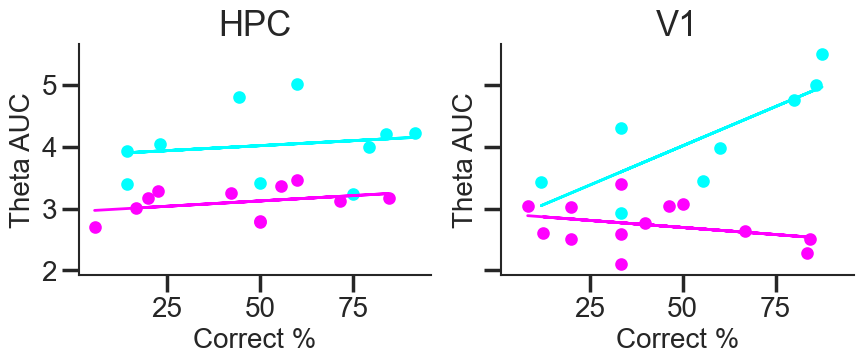

In [345]:
num_std = 1.5 # standard deviation you want to have contained within the ellipse
dot_size = 50 # aesthetic choice for the size of the scatter plot dots
plot_linReg = True

pt1_above_thresh_df = above_thresh_df[above_thresh_df.behav=="H/CR"]
idx=0
fig,ax = plt.subplots(1,2, figsize=(10,3), sharey=True, sharex=True)
for d,dd in pt1_above_thresh_df.groupby("region"): # THIS IS INCORPORATING BOTH THE GO AND NO_GO TRIALS TOGETHER FOR THE CORRECT RESPONSES ONLY
    dd = dd.dropna()
    x = dd[(dd.group=='WT')]['perc'].values
    y = dd[(dd.group=='WT')]['corr_auc'].values
    x1 = dd[(dd.group=='FX')]['perc'].values
    y1 = dd[(dd.group=='FX')]['corr_auc'].values
    # plot linear regression of the points & print R**2 value of the fit
    if plot_linReg:
        res, res1 = sstat.linregress(x, y), sstat.linregress(x1, y1)
        print(f"------------- {d} -------------")
        print(f'Slope: WT {res.slope:.6f}, FX {res1.slope:.6f}')
        print(f'R squared: WT {res.rvalue**2:.6f}, FX {res1.rvalue**2:.6f}')
        print(f'pval: WT {res.pvalue:.6f}, FX {res1.pvalue:.6f}')
        ax[idx].plot(x, res.intercept+res.slope*x, color='cyan')
        ax[idx].plot(x1, res1.intercept+res1.slope*x1, color='magenta')
    # Plot scatter
    ax[idx].scatter(x, y, s=dot_size, edgecolors=None, color='cyan', label='WT')
    ax[idx].scatter(x1, y1, s=dot_size, edgecolors=None, color='magenta', label='FX')
    ax[idx].set_xlabel("Correct %")
    ax[idx].set_ylabel('Theta AUC')
    ax[idx].set_title(d)
    idx+=1
sns.despine()
plt.show()

In [ ]:
# the results above show a significant correlation with correct behavior response and Theta AUC for WT V1!! this is in theresholded trials above mean+1std

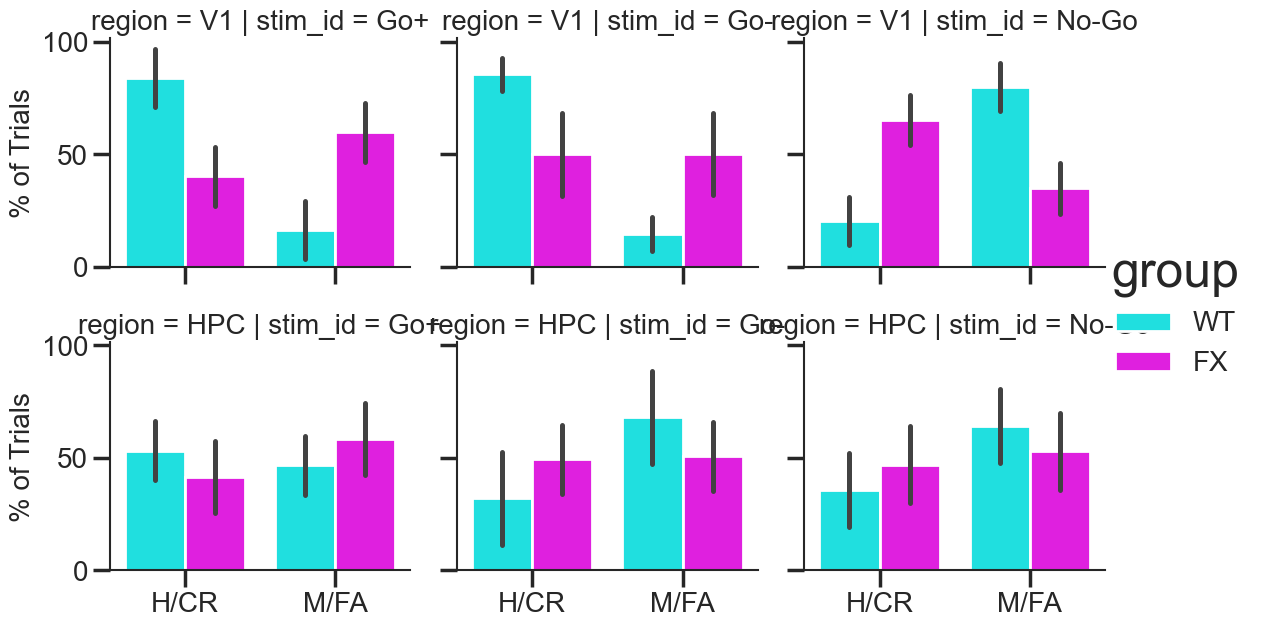

----------- WT/FX -----------
('HPC', 'Go+') H/CR 8 6 0.5172205247346372 ns
('HPC', 'Go+') M/FA 8 6 0.5172205247346372 ns
('HPC', 'Go-') H/CR 5 5 0.3946625491175668 ns
('HPC', 'Go-') M/FA 5 5 0.3946625491175668 ns
('HPC', 'No-Go') H/CR 7 6 0.7685052033457015 ns
('HPC', 'No-Go') M/FA 7 6 0.7685052033457015 ns
('V1', 'Go+') H/CR 5 6 0.08949158251335175 ns
('V1', 'Go+') M/FA 5 6 0.08949158251335175 ns
('V1', 'Go-') H/CR 5 6 0.3040493256791892 ns
('V1', 'Go-') M/FA 5 6 0.3040493256791892 ns
('V1', 'No-Go') H/CR 5 6 0.04364258227420527 *
('V1', 'No-Go') M/FA 5 6 0.04364258227420527 *
----------- C/IC -----------
('HPC', 'Go+') FX 6 6 0.5196411841272132 ns
('HPC', 'Go+') WT 8 8 0.9161747074605952 ns
('HPC', 'Go-') FX 5 5 1.0 ns
('HPC', 'Go-') WT 5 5 0.26520539259150755 ns
('HPC', 'No-Go') FX 6 6 0.6847135504649174 ns
('HPC', 'No-Go') WT 7 7 0.23954811977114854 ns
('V1', 'Go+') FX 6 6 0.2962580613588991 ns
('V1', 'Go+') WT 5 5 0.018490777408429176 *
('V1', 'Go-') FX 6 6 0.935276611110665 ns
(

In [323]:
g = sns.catplot(data=above_thresh_df, x='behav', y='perc', kind='bar', hue='group', row='region', row_order=['V1', 'HPC'], col='stim_id', errorbar='se', height=3.5, aspect=1.1)
g.set(xlabel='', ylabel='% of Trials')
# plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\barplot_thresholdTrialPercent.pdf", transparent=True)
plt.show()

print('----------- WT/FX -----------') # stats for comparing WT/FX
for d,dd in above_thresh_df.groupby(["region","stim_id"]):
    for e,ee in dd.groupby('behav'):
        x,y = ee[ee.group=='WT'].perc.values, ee[ee.group=='FX'].perc.values
        num_x,num_y = ee[ee.group=='WT'].et.nunique(), ee[ee.group=='FX'].et.nunique()
        u,p = sstat.mannwhitneyu(x,y)
        print(d,e,num_x,num_y,p,"***" if p<0.001 else ("**" if p<0.01 else "*" if p<0.05 else "ns"))

print('----------- C/IC -----------') # stats for comparing within group
for d,dd in above_thresh_df.groupby(["region","stim_id"]):
    for e,ee in dd.groupby('group'):
        x,y = ee[ee.behav=='H/CR'].perc.values, ee[ee.behav=='M/FA'].perc.values
        num_x,num_y = ee[ee.behav=='H/CR'].et.nunique(), ee[ee.behav=='M/FA'].et.nunique()
        u,p = sstat.mannwhitneyu(x,y)
        print(d,e,num_x,num_y,p,"***" if p<0.001 else ("**" if p<0.01 else "*" if p<0.05 else "ns"))

# Logistic regression on the trial by trial data - MZ 03.07.25

In [312]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import statsmodels.api as sm

theta_lfp_fft = lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et.isin(active_ets))]
theta_lfp_fft.head(2)

,trial,band,mean_val,peak_val,auc,et,region,group,stim_id,num_licks,behav
1,0,"[4, 8]",4.377809,7.915976,1.034116,CC067431_HP2,V1,FX,Go+,0,M
1,0,"[4, 8]",14.050347,33.846863,2.667414,CC067431_HP2,HPC,FX,Go+,0,M


Optimization terminated successfully.
         Current function value: 0.693092
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  720
Model:                          Logit   Df Residuals:                      719
Method:                           MLE   Df Model:                            0
Date:                Thu, 13 Mar 2025   Pseudo R-squ.:              -0.0001929
Time:                        15:31:01   Log-Likelihood:                -499.03
converged:                       True   LL-Null:                       -498.93
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0100      0.035     -0.282      0.778      -0.080       0.060
pvals: [0.77766913] -- ns

[[

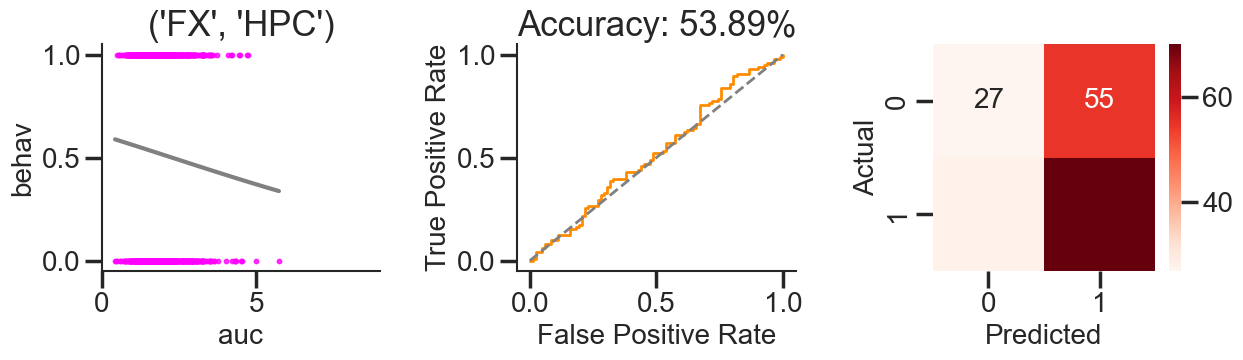

Optimization terminated successfully.
         Current function value: 0.693147
         Iterations 2
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  720
Model:                          Logit   Df Residuals:                      719
Method:                           MLE   Df Model:                            0
Date:                Thu, 13 Mar 2025   Pseudo R-squ.:              -0.0002727
Time:                        15:31:01   Log-Likelihood:                -499.07
converged:                       True   LL-Null:                       -498.93
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0004      0.042      0.009      0.993      -0.082       0.083
pvals: [0.99289575] -- ns

[[

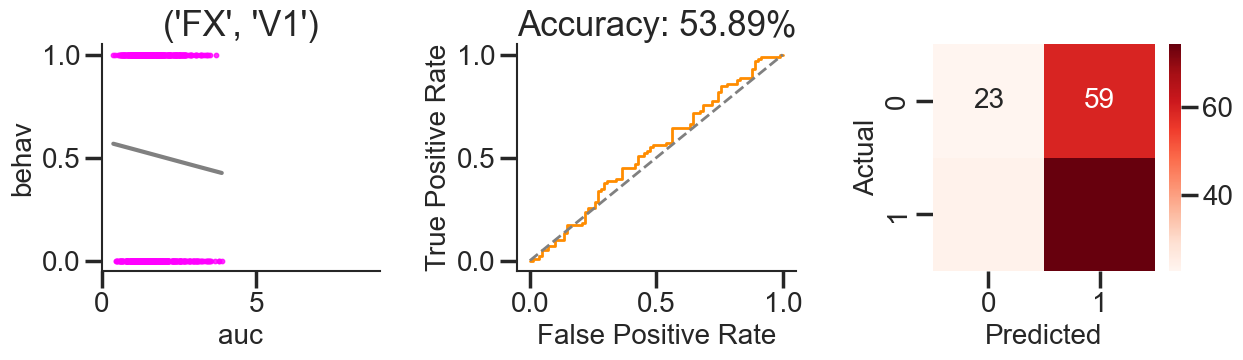

Optimization terminated successfully.
         Current function value: 0.690892
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  960
Model:                          Logit   Df Residuals:                      959
Method:                           MLE   Df Model:                            0
Date:                Thu, 13 Mar 2025   Pseudo R-squ.:               4.523e-05
Time:                        15:31:01   Log-Likelihood:                -663.26
converged:                       True   LL-Null:                       -663.29
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0551      0.027      2.076      0.038       0.003       0.107
pvals: [0.03786507] -- *

[[ 

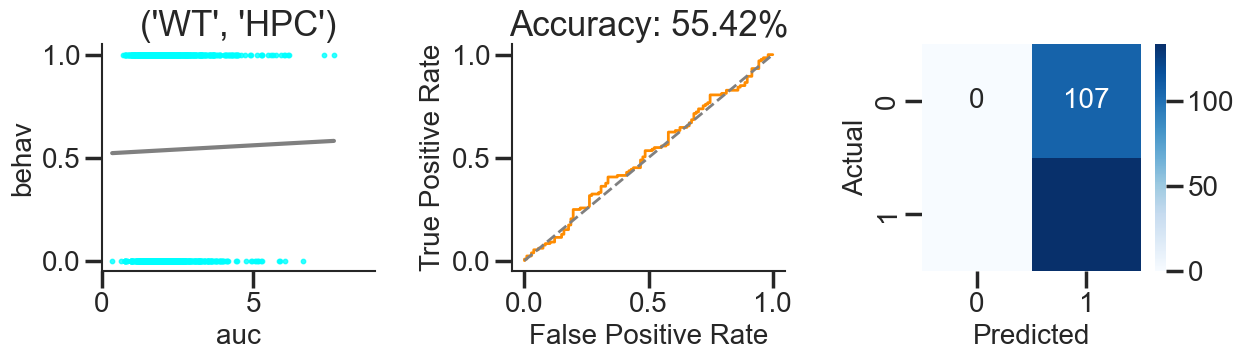

Optimization terminated successfully.
         Current function value: 0.684364
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  960
Model:                          Logit   Df Residuals:                      959
Method:                           MLE   Df Model:                            0
Date:                Thu, 13 Mar 2025   Pseudo R-squ.:                0.009493
Time:                        15:31:02   Log-Likelihood:                -656.99
converged:                       True   LL-Null:                       -663.29
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1050      0.026      4.070      0.000       0.054       0.156
pvals: [4.71026363e-05] -- **

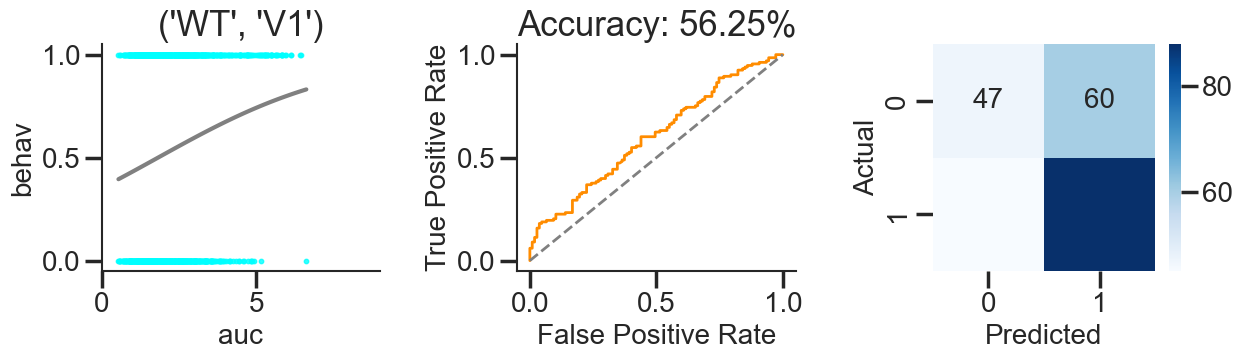

In [456]:
is_plot = True
run_stats = True

for d,dd in theta_lfp_fft.groupby(['group', 'region']): #combine all Go and No-Go trials together
# for d,dd in theta_lfp_fft[theta_lfp_fft.stim_id!='No-Go'].groupby(['group','region']): #Only look at Go trials
# for d,dd in theta_lfp_fft[theta_lfp_fft.stim_id=='No-Go'].groupby(['group','region']): #Only look at No-Go trials
    X = dd.auc.to_numpy().reshape(-1,1)
    foo = dd.behav.values
    y_binary = np.select([foo=='H', foo=='M', foo=='CR', foo=='FA'], [1,0,1,0], foo).astype('int32') #replace behavior with 1 or 0 if correct or incorrect (BOTH GO AND NO-GO INCLUDED)
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    # Train the Logistic Regression model
    model = LogisticRegression()
    model.fit(X_train, y_train)
    # Evaluate the model
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    if run_stats:
        X = dd.auc.to_numpy().reshape(-1,1)
        foo = dd.behav.values
        y_binary = np.select([foo=='H', foo=='M', foo=='CR', foo=='FA'], [1,0,1,0], foo).astype('int32') #replace behavior outcome with 1 or 0
        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
        # building the model and fitting the data 
        log_reg = sm.Logit(y_train, X_train).fit()
        pstar = '***' if log_reg.pvalues < 0.001 else ('**' if log_reg.pvalues < 0.01 else ('*' if log_reg.pvalues < 0.05 else 'ns'))
        print(log_reg.summary())
        print(f"pvals: {log_reg.pvalues} -- {pstar}\n")
        
    if is_plot:
        # Plot logistic regression fit Curve
        fig,ax = plt.subplots(1,3, figsize=(13,4))
        data = pd.DataFrame({'auc': dd.auc.to_numpy(), 'behav': y_binary})
        sns.regplot(x=data['auc'], y=data['behav'], data=data, logistic=True, ci=None, color="cyan" if d[0]=='WT' else 'magenta', 
                    scatter_kws={'s': 10}, line_kws={'color': 'gray'}, ax=ax[0])
        ax[0].set_title(d)
        ax[0].set_xlim([0,9])
        sns.despine(ax=ax[0])
        
        # Plot ROC Curve
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
        ax[1].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random')
        ax[1].set_xlabel('False Positive Rate')
        ax[1].set_ylabel('True Positive Rate')
        ax[1].set_title(f'Accuracy: {accuracy * 100:.2f}%')
        sns.despine(ax=ax[1])
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        print(cm)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if d[0]=='WT' else 'Reds', ax=ax[2])
        ax[2].set_xlabel('Predicted')
        ax[2].set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

In [317]:
# similar code to the above cell, just doesn't plot and saves accuracy values to a DataFrame
accuracy_ls = []
for stim in ['Go', 'No-Go']:
    if stim == 'Go':
        foo_df = theta_lfp_fft[theta_lfp_fft.stim_id!='No-Go']
    else:
        foo_df = theta_lfp_fft[theta_lfp_fft.stim_id=='No-Go']
    for d,dd in foo_df.groupby(['group', 'region', 'et']): #combine all Go and No-Go trials together
        try:
            X = dd.auc.to_numpy().reshape(-1,1)
            foo = dd.behav.values
            y_binary = np.select([foo=='H', foo=='M', foo=='CR', foo=='FA'], [1,0,1,0], foo).astype('int32') #replace behavior with 1 or 0 if correct or incorrect (BOTH GO AND NO-GO INCLUDED)
            # Split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
            # Standardize features
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            # Train the Logistic Regression model
            model = LogisticRegression()
            model.fit(X_train, y_train)
            # Evaluate the model
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            accuracy_ls.append(pd.DataFrame({'Accuracy': [accuracy], 'et': d[2], 'group': d[0], 'region':d[1], 'stim_id':[stim]}))
        except:
            continue
accuracy_df = pd.concat(accuracy_ls, ignore_index=True)
accuracy_df.head()

,Accuracy,et,group,region,stim_id
0,0.80,CC067431_HP2,FX,HPC,Go
1,0.95,CC067432_HP3,FX,HPC,Go
2,0.75,CC067432_HP4,FX,HPC,Go
3,0.80,CC082255_HP0,FX,HPC,Go
4,0.40,CC082255_HP3,FX,HPC,Go


wt -- ShapiroResult(statistic=0.9038289785385132, pvalue=0.3126438558101654)
fx -- ShapiroResult(statistic=0.9215709567070007, pvalue=0.5167472958564758)
('Go', 'HPC') -- TtestResult(statistic=0.5416312188036909, pvalue=0.5979854709693215, df=12.0) -- ns
wt -- ShapiroResult(statistic=0.8910680413246155, pvalue=0.23943692445755005)
fx -- ShapiroResult(statistic=0.9066998958587646, pvalue=0.41504400968551636)
('Go', 'V1') -- TtestResult(statistic=1.416675206642291, pvalue=0.18201162855264613, df=12.0) -- ns
wt -- ShapiroResult(statistic=0.8662582039833069, pvalue=0.13850684463977814)
fx -- ShapiroResult(statistic=0.9427295327186584, pvalue=0.685295045375824)
('No-Go', 'HPC') -- TtestResult(statistic=0.27531447354739247, pvalue=0.7881775086020457, df=11.0) -- ns
wt -- ShapiroResult(statistic=0.9132676124572754, pvalue=0.3776489496231079)
fx -- ShapiroResult(statistic=0.8707032203674316, pvalue=0.26928290724754333)
('No-Go', 'V1') -- TtestResult(statistic=0.7281119968142377, pvalue=0.48175

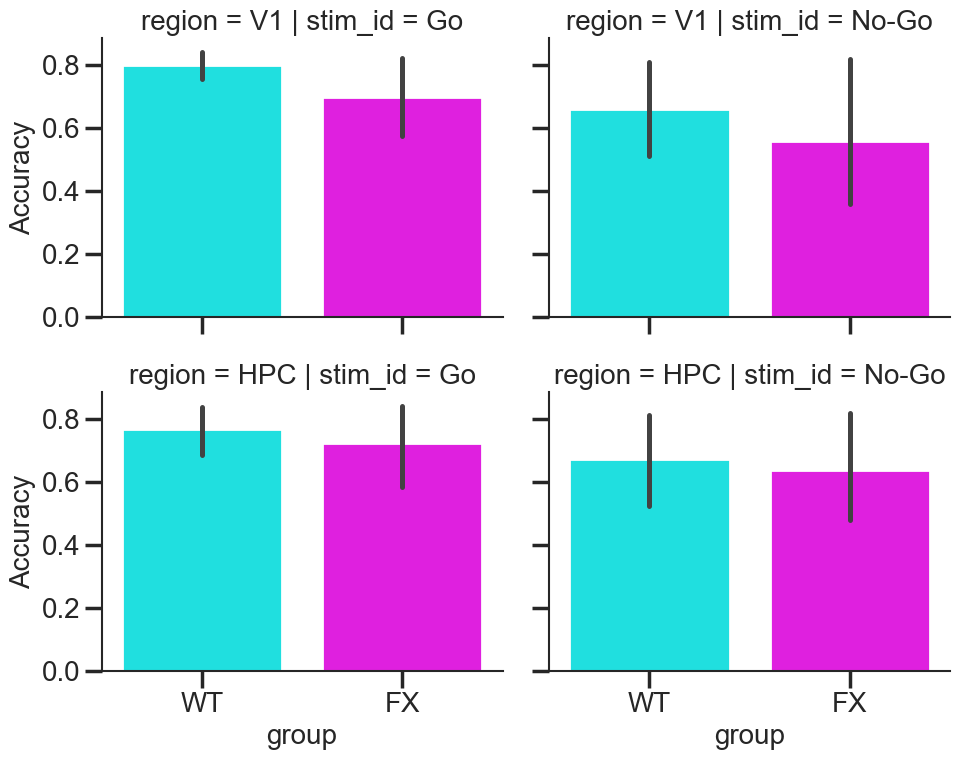

In [327]:
sns.catplot(data=accuracy_df, kind="bar", x="group", y="Accuracy", order=['WT', 'FX'], 
            col='stim_id', col_order=['Go', 'No-Go'], row='region', row_order=['V1', 'HPC'],
            height=4, aspect=1.25)

for d,dd in accuracy_df.groupby(['stim_id', 'region']):
    x = dd[dd.group=='WT'].Accuracy.values
    y = dd[dd.group=='FX'].Accuracy.values
    res = sstat.shapiro(x)
    print("wt --", res)
    res = sstat.shapiro(y)
    print("fx --", res)
    res = sstat.ttest_ind(x, y)
    pstar = '***' if res.pvalue < 0.001 else ('**' if res.pvalue < 0.01 else ('*' if res.pvalue < 0.05 else "ns"))
    print(f"{d} -- {res} -- {pstar}")
for d,dd in accuracy_df.groupby(['group', 'region']):
    x = dd[dd.stim_id=='Go'].Accuracy.values
    y = dd[dd.stim_id=='No-Go'].Accuracy.values
    res = sstat.ttest_ind(x, y)
    pstar = '***' if res.pvalue < 0.001 else ('**' if res.pvalue < 0.01 else ('*' if res.pvalue < 0.05 else "ns"))
    print(f"{d} -- {res} -- {pstar}")

plt.show()

# ! 2d scatter plots for lick prob and behavior for the LFP data

In [ ]:
osc_characteristic = 'auc' #'auc', 'mean_val', 'peak_val'
go_evidence = []
for d,dd in lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et.isin(active_ets))].groupby(['et','region']):
    go_c = dd[(dd.stim_id=='Go+')&(dd.behav=='H')|(dd.stim_id=='Go-')&(dd.behav=='H')][osc_characteristic].mean()
    go_i = dd[(dd.stim_id=='Go+')&(dd.behav=='M')|(dd.stim_id=='Go-')&(dd.behav=='M')][osc_characteristic].mean()
    go_all = dd[(dd.stim_id=='Go+')|(dd.stim_id=='Go-')][osc_characteristic].mean()
    ng_c = dd[(dd.stim_id=='No-Go')&(dd.behav=='CR')][osc_characteristic].mean()
    ng_i = dd[(dd.stim_id=='No-Go')&(dd.behav=='FA')][osc_characteristic].mean()
    ng_all = dd[dd.stim_id=='No-Go'][osc_characteristic].mean()
    go = (go_c-go_i)/(go_c+go_i)
    ng = (ng_c-ng_i)/(ng_c+ng_i)
    g_ng = (go-ng)/(go+ng)
    go_base = (go_c-go_all)/(dd[(dd.stim_id=='Go+')|(dd.stim_id=='Go-')][osc_characteristic].std())
    ng_base = (ng_c-ng_all)/(dd[dd.stim_id=='No-Go'][osc_characteristic].std())
    lick_dict = dd.groupby('behav').trial.nunique().to_dict()
    d_prime = sstat.norm.ppf(lick_dict['H']/100) - sstat.norm.ppf(lick_dict['FA']/50)
    go_evidence.append(pd.DataFrame({'goC':go_c, 'goIC':go_i,'ngC':ng_c, 'ngIC':ng_i, 'go_avg':go, 'ng_avg':ng, 'gng_avg':g_ng, 'go_base':go_base, 'ng_base':ng_base,
                                     'go_licks':lick_dict['H']/100, 'ng_licks':lick_dict['CR']/50, 'gng_licks':(lick_dict['H']+lick_dict['CR'])/150, 'Dprime':d_prime, 
                                     'go2_licks':lick_dict['M']/100, 'ng2_licks':lick_dict['FA']/50,
                                     'et':d[0], 'group':dd.group.unique()[0], 'region':d[1]}, index=[0]))
go_evidence = pd.concat(go_evidence, ignore_index=True)
go_evidence.head()

In [26]:
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.
    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.
    ax : matplotlib.axes.Axes
        The Axes object to draw the ellipse into.
    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.
    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`
    Returns
    -------
    matplotlib.patches.Ellipse
    CODE FROM: https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html#sphx-glr-gallery-statistics-confidence-ellipse-py
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor=facecolor, **kwargs)
    # Calculating the standard deviation of x from the squareroot of the variance and multiplying with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

------------- go2_licks -------------
V1 - Slope: WT -0.727799, FX 0.179037
V1 - R squared: WT 0.168820, FX 0.077823
V1 - pval: WT 0.311919, FX 0.592403
------------- go2_licks -------------
HPC - Slope: WT -0.247800, FX 0.332977
HPC - R squared: WT 0.033683, FX 0.096113
HPC - pval: WT 0.663531, FX 0.549868


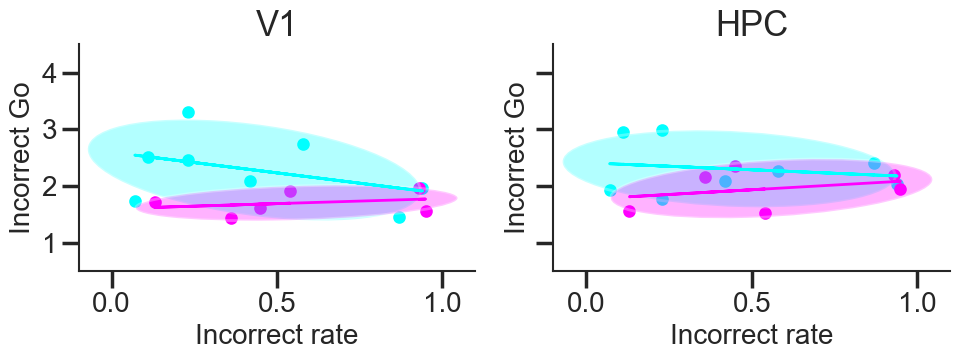

------------- ng2_licks -------------
V1 - Slope: WT 0.725323, FX 0.337890
V1 - R squared: WT 0.195770, FX 0.075781
V1 - pval: WT 0.272306, FX 0.597505
------------- ng2_licks -------------
HPC - Slope: WT -0.533163, FX 0.256496
HPC - R squared: WT 0.090847, FX 0.021247
HPC - pval: WT 0.468154, FX 0.782905


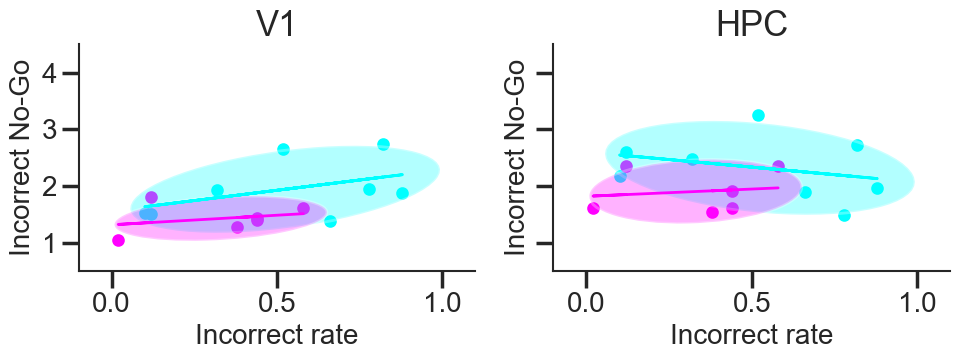

In [55]:
num_std = 1.5 # standard deviation you want to have contained within the ellipse
dot_size = 50 # aesthetic choice for the size of the scatter plot dots
plot_linReg = True # adds a linear regression to the 2d scatter (with the ellipse)

# for val in [['go_licks', 'go_base'], ['ng_licks', 'ng_base']]:
# for val in [['go_licks', 'go_avg'], ['ng_licks', 'ng_avg'], ['gng_licks', 'gng_avg'], ['Dprime', 'gng_avg']]:
# for val in [['go_licks', 'goC'], ['ng_licks', 'ngC']]:
for val in [['go2_licks', 'goIC'], ['ng2_licks', 'ngIC']]:
    my_x, my_y = val[0], val[1]
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    for idx, reg in enumerate(['V1','HPC']):
        x = go_evidence[(go_evidence.group=='WT')&(go_evidence.region==reg)][my_x].values
        y = go_evidence[(go_evidence.group=='WT')&(go_evidence.region==reg)][my_y].values
        x1 = go_evidence[(go_evidence.group=='FX')&(go_evidence.region==reg)][my_x].values
        y1 = go_evidence[(go_evidence.group=='FX')&(go_evidence.region==reg)][my_y].values
        # plot linear regression of the points & print R**2 value of the fit
        if plot_linReg:
            res, res1 = sstat.linregress(x, y), sstat.linregress(x1, y1)
            print(f"------------- {my_x} -------------")
            print(f'{reg} - Slope: WT {res.slope:.6f}, FX {res1.slope:.6f}')
            print(f'{reg} - R squared: WT {res.rvalue**2:.6f}, FX {res1.rvalue**2:.6f}')
            print(f'{reg} - pval: WT {res.pvalue:.6f}, FX {res1.pvalue:.6f}')
            ax[idx].plot(x, res.intercept+res.slope*x, color='cyan')
            ax[idx].plot(x1, res1.intercept+res1.slope*x1, color='magenta')
        # Plot scatter
        ax[idx].scatter(x, y, s=dot_size, edgecolors=None, color='cyan', label='WT')
        ax[idx].scatter(x1, y1, s=dot_size, edgecolors=None, color='magenta', label='FX')
        # Plot ellipse using above function
        confidence_ellipse(x, y, ax[idx], n_std=num_std, edgecolor=None, facecolor='cyan', alpha=0.3)
        confidence_ellipse(x1, y1, ax[idx], n_std=num_std, edgecolor=None, facecolor='magenta', alpha=0.3)
        if my_x == 'gng_licks':
            ax[idx].set_xlim([0,1.1])
            # ax[idx].set_ylim([0.45,0.57])
            ax[idx].set_xlabel("Correct %")
            ax[idx].set_ylabel("GNG Theta")
        elif my_x == 'Dprime':
            ax[idx].set_xlim([-1,2])
            # ax[idx].set_ylim([0.45,0.57])
            ax[idx].set_xlabel("d'")
            ax[idx].set_ylabel("GNG Theta")
        else:
            ax[idx].set_xlim([-0.1,1.1])
            ax[idx].set_xlabel("Correct rate")
            if (my_y=='go_avg')|(my_y=='ng_avg'):
                ax[idx].set_ylabel("Go Theta") if my_x=='go_licks' else ax[idx].set_ylabel("No-Go Theta")
            else:
                if (my_y=='goIC')|(my_y=='ngIC'):
                    ax[idx].set_ylabel("Incorrect Go") if my_x=='go2_licks' else ax[idx].set_ylabel("Incorrect No-Go")
                    ax[idx].set_ylim([0.5,4.5])
                    ax[idx].set_xlabel("Incorrect rate")
                else:
                    ax[idx].set_ylabel("Correct Go") if my_x=='go_licks' else ax[idx].set_ylabel("Correct No-Go")
                    ax[idx].set_ylim([0.5,4.5])
        ax[idx].set_title(reg)
    plt.tight_layout()
    sns.despine()
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\2dscatter_LFP_incorrectTrials_{my_x}_v1hpc.pdf", transparent=True)
    plt.show()

In [124]:
# Calculate a Spearman correlation coefficient with associated p-value on the 2d scatter plots
def statistic(x): # permute only `x`
    return sstat.spearmanr(x, y).statistic
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html            <--- Spearman test info
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.permutation_test.html     <--- Permutation info

# for val in [['go_licks', 'go_avg'], ['ng_licks', 'ng_avg'], ['gng_licks', 'gng_avg'], ['Dprime', 'gng_avg']]:
for val in [['go_licks', 'goC'], ['ng_licks', 'ngC'], ['go2_licks', 'goIC'], ['ng2_licks', 'ngIC']]:
    my_x, my_y = val[0], val[1]
    for idx, reg in enumerate(['V1','HPC']):
        for g in ['WT', 'FX']:
            x = go_evidence[(go_evidence.group==g)&(go_evidence.region==reg)][my_x].values
            y = go_evidence[(go_evidence.group==g)&(go_evidence.region==reg)][my_y].values
            res_exact = sstat.permutation_test((x,), statistic, permutation_type='pairings')
            print(val, reg, g)
            pval = "***" if res_exact.pvalue < 0.001 else ("**" if res_exact.pvalue<0.01 else ("*" if res_exact.pvalue <0.05 else "ns"))
            print(f"stat = {res_exact.statistic:.6f} -- pval = {res_exact.pvalue:.6f} -- {pval}")

['go_licks', 'goC'] V1 WT
stat = 0.514979 -- pval = 0.198600 -- ns
['go_licks', 'goC'] V1 FX
stat = -0.771429 -- pval = 0.102778 -- ns
['go_licks', 'goC'] HPC WT
stat = -0.059881 -- pval = 0.884800 -- ns
['go_licks', 'goC'] HPC FX
stat = -0.600000 -- pval = 0.241667 -- ns
['ng_licks', 'ngC'] V1 WT
stat = -0.500000 -- pval = 0.218000 -- ns
['ng_licks', 'ngC'] V1 FX
stat = -0.115954 -- pval = 0.838889 -- ns
['ng_licks', 'ngC'] HPC WT
stat = 0.333333 -- pval = 0.431800 -- ns
['ng_licks', 'ngC'] HPC FX
stat = -0.028989 -- pval = 0.983333 -- ns
['go2_licks', 'goIC'] V1 WT
stat = -0.227549 -- pval = 0.599600 -- ns
['go2_licks', 'goIC'] V1 FX
stat = 0.200000 -- pval = 0.713889 -- ns
['go2_licks', 'goIC'] HPC WT
stat = 0.035929 -- pval = 0.943600 -- ns
['go2_licks', 'goIC'] HPC FX
stat = 0.085714 -- pval = 0.919444 -- ns
['ng2_licks', 'ngIC'] V1 WT
stat = 0.404762 -- pval = 0.326000 -- ns
['ng2_licks', 'ngIC'] V1 FX
stat = 0.405840 -- pval = 0.433333 -- ns
['ng2_licks', 'ngIC'] HPC WT
stat = -

In [110]:
# trying a 2-dimensional, 2-sample KS test for comparing the WT and FX groups (https://github.com/syrte/ndtest)
import ndtest

for val in [['go_licks', 'goC'], ['ng_licks', 'ngC'], ['go2_licks', 'goIC'], ['ng2_licks', 'ngIC']]: #correct/incorrect trial responses only
    my_x, my_y = val[0], val[1]
    for idx, reg in enumerate(['V1','HPC']):
        x = go_evidence[(go_evidence.group=='WT')&(go_evidence.region==reg)][my_x].values
        y = go_evidence[(go_evidence.group=='WT')&(go_evidence.region==reg)][my_y].values
        x1 = go_evidence[(go_evidence.group=='FX')&(go_evidence.region==reg)][my_x].values
        y1 = go_evidence[(go_evidence.group=='FX')&(go_evidence.region==reg)][my_y].values
        P, D = ndtest.ks2d2s(x, y, x1, y1, extra=True)
        pval = "***" if P<0.001 else ("**" if P<0.01 else ("*" if P<0.05 else "ns"))
        print(f"{my_y} -- {reg} -- d={D:.7f} -- p={P:.7f} -- {pval}")

goC -- V1 -- d=0.6666667 -- p=0.0382873 -- *
goC -- HPC -- d=0.5208333 -- p=0.1573250 -- ns
ngC -- V1 -- d=0.6041667 -- p=0.0661087 -- ns
ngC -- HPC -- d=0.6666667 -- p=0.0289428 -- *
goIC -- V1 -- d=0.6041667 -- p=0.0650767 -- ns
goIC -- HPC -- d=0.4583333 -- p=0.2717702 -- ns
ngIC -- V1 -- d=0.6666667 -- p=0.0311975 -- *
ngIC -- HPC -- d=0.6875000 -- p=0.0223816 -- *


In [125]:
# # trying a multivariate ANOVA test (https://www.reneshbedre.com/blog/manova-python.html)
# # https://www.statsmodels.org/stable/generated/statsmodels.multivariate.manova.MANOVA.html#statsmodels.multivariate.manova.MANOVA
# from statsmodels.multivariate.manova import MANOVA

# for reg in ['V1','HPC']:
#     region_df = go_evidence[go_evidence.region==reg]
#     fit = MANOVA.from_formula('go_licks + goC ~ group', data=region_df)
#     print(f'goC -- {reg}')
#     print(fit.mv_test())

# for reg in ['V1','HPC']:
#     region_df = go_evidence[go_evidence.region==reg]
#     fit = MANOVA.from_formula('ng_licks + ngC ~ group', data=region_df)
#     print(f'goC -- {reg}')
#     print(fit.mv_test())

In [126]:
# # Trying Linear Mixed Model (https://www.statsmodels.org/stable/mixed_linear.html)
# import statsmodels.formula.api as smf

# for reg in ['V1','HPC']:
#     region_df = go_evidence[go_evidence.region==reg]
#     md = smf.mixedlm("goC ~ go_licks", region_df, groups=region_df["group"], re_formula="~go_licks")
#     mdf = md.fit(method=["lbfgs"])
#     print(mdf.summary())

# for reg in ['V1','HPC']:
#     region_df = go_evidence[go_evidence.region==reg]
#     md = smf.mixedlm("ngC ~ ng_licks", region_df, groups=region_df["group"], re_formula="~ng_licks")
#     mdf = md.fit(method=["lbfgs"])
#     print(mdf.summary())

## ! 2d scatter plots for lick prob and behavior for the units data

In [ ]:
display(units_fft.head(2))
display(vr_units.head(2))

In [ ]:
osc_characteristic = 'auc'
go_evid_units = []
for d,dd in units_fft[(units_fft.band=="[4, 8]")&(units_fft.et.isin(active_ets))].groupby(['et','region']):
    go = dd[(dd.stim==0)|(dd.stim==1)][osc_characteristic].mean()
    ng = dd[(dd.stim==2)][osc_characteristic].mean()
    g_ng = go/(go+ng)
    go_evid_units.append(pd.DataFrame({'go_avg':go, 'ng_avg':ng, 'gng_avg':g_ng, 'et':d[0], 'group':dd.group.unique()[0], 'region':d[1]}, index=[0]))
go_evid_units = pd.concat(go_evid_units, ignore_index=True)
#map lick probability values from LFP df to units df
map_dict = dict(zip(go_evidence['et'], go_evidence['gng_licks']))
go_evid_units['gng_licks'] = go_evid_units['et'].map(map_dict)
map_dict = dict(zip(go_evidence['et'], go_evidence['go_licks']))
go_evid_units['go_licks'] = go_evid_units['et'].map(map_dict)
map_dict = dict(zip(go_evidence['et'], go_evidence['ng_licks']))
go_evid_units['ng_licks'] = go_evid_units['et'].map(map_dict)
map_dict = dict(zip(go_evidence['et'], go_evidence['Dprime']))
go_evid_units['Dprime'] = go_evid_units['et'].map(map_dict)
go_evid_units.head()

In [ ]:
num_std = 1.5 # standard deviation you want to have contained within the ellipse
dot_size = 50 # aesthetic choice for the size of the scatter plot dots
plot_linReg = False # adds a linear regression to the 2d scatter (with the ellipse)

for val in [['go_licks', 'go_avg'], ['ng_licks', 'ng_avg'], ['gng_licks', 'gng_avg'], ['Dprime', 'gng_avg']]:
    my_x, my_y = val[0], val[1]
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    for idx, reg in enumerate(['v1','hippo']):
        x = go_evid_units[(go_evid_units.group=='WT')&(go_evid_units.region==reg)][my_x].values
        y = go_evid_units[(go_evid_units.group=='WT')&(go_evid_units.region==reg)][my_y].values
        x1 = go_evid_units[(go_evid_units.group=='FX')&(go_evid_units.region==reg)][my_x].values
        y1 = go_evid_units[(go_evid_units.group=='FX')&(go_evid_units.region==reg)][my_y].values
        # plot linear regression of the points & print R**2 value of the fit
        if plot_linReg:
            res, res1 = sstat.linregress(x, y), sstat.linregress(x1, y1)
            print(f'{reg} - Slope: WT {res.slope:.6f}, FX {res1.slope:.6f}')
            print(f'{reg} - R squared: WT {res.rvalue**2:.6f}, FX {res1.rvalue**2:.6f}')
            ax[idx].plot(x, res.intercept+res.slope*x, color='cyan')
            ax[idx].plot(x1, res1.intercept+res1.slope*x1, color='magenta')
        # Plot scatter
        ax[idx].scatter(x, y, s=dot_size, edgecolors=None, color='cyan', label='WT')
        ax[idx].scatter(x1, y1, s=dot_size, edgecolors=None, color='magenta', label='FX')
        # Plot ellipse using above function
        confidence_ellipse(x, y, ax[idx], n_std=num_std, edgecolor='cyan', facecolor='cyan', alpha=0.2)
        confidence_ellipse(x1, y1, ax[idx], n_std=num_std, edgecolor='magenta', facecolor='magenta', alpha=0.2)
        if my_x == 'gng_licks':
            ax[idx].set_xlim([0,1.1])
            # ax[idx].set_ylim([0.45,0.57])
            ax[idx].set_xlabel("Lick probability")
            ax[idx].set_ylabel("GNG Theta")
        elif my_x == 'Dprime':
            ax[idx].set_xlim([-1,2])
            # ax[idx].set_ylim([0.45,0.57])
            ax[idx].set_xlabel("d'")
            ax[idx].set_ylabel("GNG Theta")
        else:
            ax[idx].set_xlim([-0.1,1.1])
            # ax[idx].set_ylim([0.4,0.6])
            ax[idx].set_xlabel("Lick probability")
            ax[idx].set_ylabel("Go Theta") if my_x=='go_licks' else ax[idx].set_ylabel("No-Go Theta")
        ax[idx].set_title(f"{reg} units")
    plt.tight_layout()
    sns.despine()
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\2dscatter_units_{my_x}_v1hpc.pdf", transparent=True)
    plt.show()

# ! LFP trace, unit rasters, and lick behavior

In [351]:
unit_spikes = pd.read_pickle(r"U:\Papers\FX Behavior paper\data\operant_spikes_df.pkl")
unit_spikes.head()

,cluster_id,spikes,trial,stim_id,trial_spikes,depth,cuid,group,set,region,et,cc,path
0.0,770,0.003133,0.0,0,0.003133,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...
0.0,770,0.044700,0.0,0,0.044700,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...
0.0,770,0.120567,0.0,0,0.120567,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...
0.0,770,0.170067,0.0,0,0.170067,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...
0.0,770,0.236600,0.0,0,0.236600,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...


In [116]:
# #plot rasters for all units to decide which ones to use for the final combo plots in cell below

# my_et = "CC082260_HP2" # WT mouse
# # my_et = "CC082255_HP0" # FX mouse
# stim_id = 0

# plt_color = 'cyan' if my_et == "CC082260_HP2" else 'magenta'

# et_behav = dict(zip(range(150),lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et==my_et)&(lfp_fft.region=='V1')].behav.values))
# et_spk = unit_spikes[unit_spikes.et==my_et]
# et_spk['behav'] = et_spk['trial'].map(et_behav)

# for unit in vr_units[vr_units.et==my_et].cuid.unique():
#     print(unit)
#     unit_spk = et_spk[et_spk.cuid==unit]
    
#     fig, ax = plt.subplots(2,2, figsize=(15,5), sharex=True, sharey=True)
#     ax = ax.flatten()
#     ax_titles = ['Hit', "Miss", 'CR', "FA"]
#     for idx,axis in enumerate(ax):
#         axis.axvspan(0.5 ,0.7, color='grey', alpha=0.2)
#         axis.set(ylabel='Trial #')
#         axis.set_title(ax_titles[idx])
#     #raster plots
#     ax[0].plot(unit_spk[unit_spk.behav=='H'].trial_spikes, unit_spk[unit_spk.behav=='H'].trial, '.', ms=8, color=plt_color)
#     ax[1].plot(unit_spk[unit_spk.behav=='M'].trial_spikes, unit_spk[unit_spk.behav=='M'].trial, '.', ms=8, color=plt_color)
#     ax[2].plot(unit_spk[unit_spk.behav=='CR'].trial_spikes, unit_spk[unit_spk.behav=='CR'].trial, '.', ms=8, color=plt_color)
#     ax[3].plot(unit_spk[unit_spk.behav=='FA'].trial_spikes, unit_spk[unit_spk.behav=='FA'].trial, '.', ms=8, color=plt_color)
    
#     sns.despine()
#     plt.show()
    

C:\Users\AChub_Lab\AppData\Local\Temp\ipykernel_17248\1023926284.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  et_spk['behav'] = et_spk['trial'].map(et_behav)


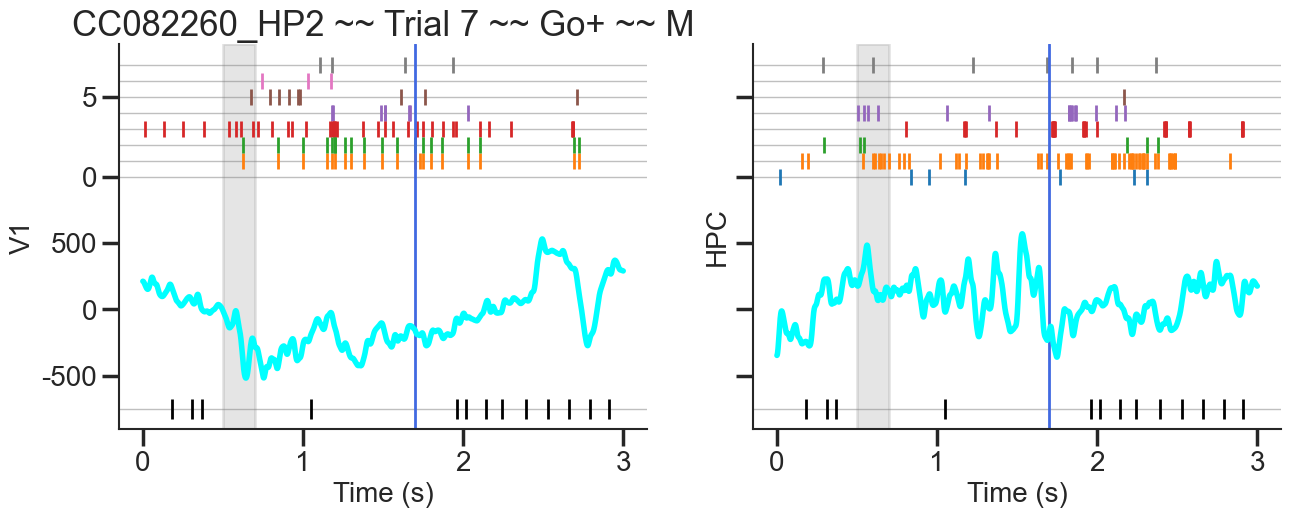

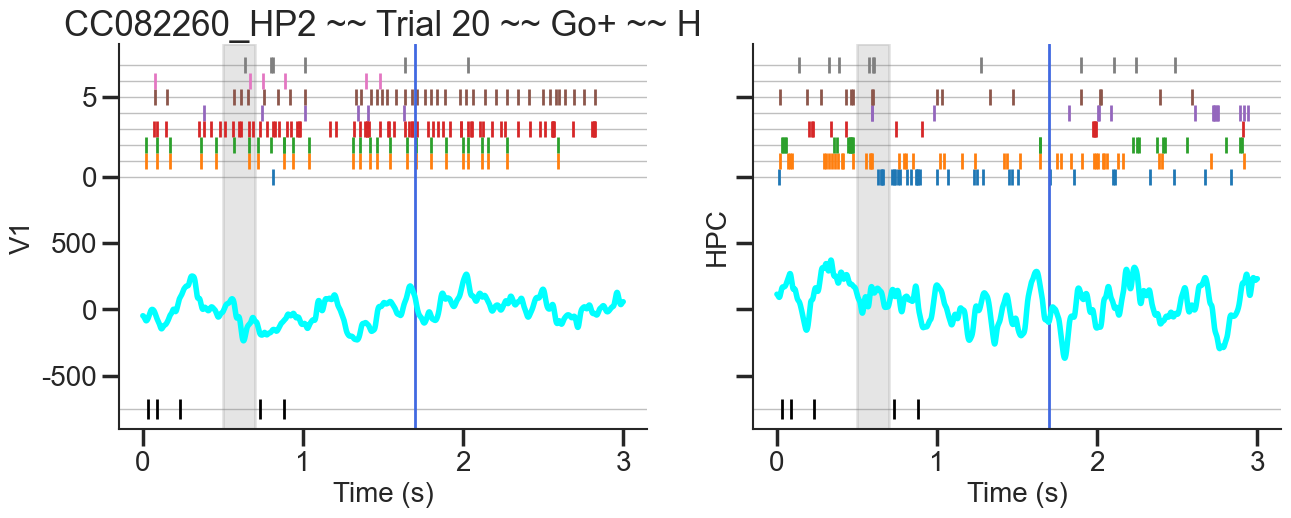

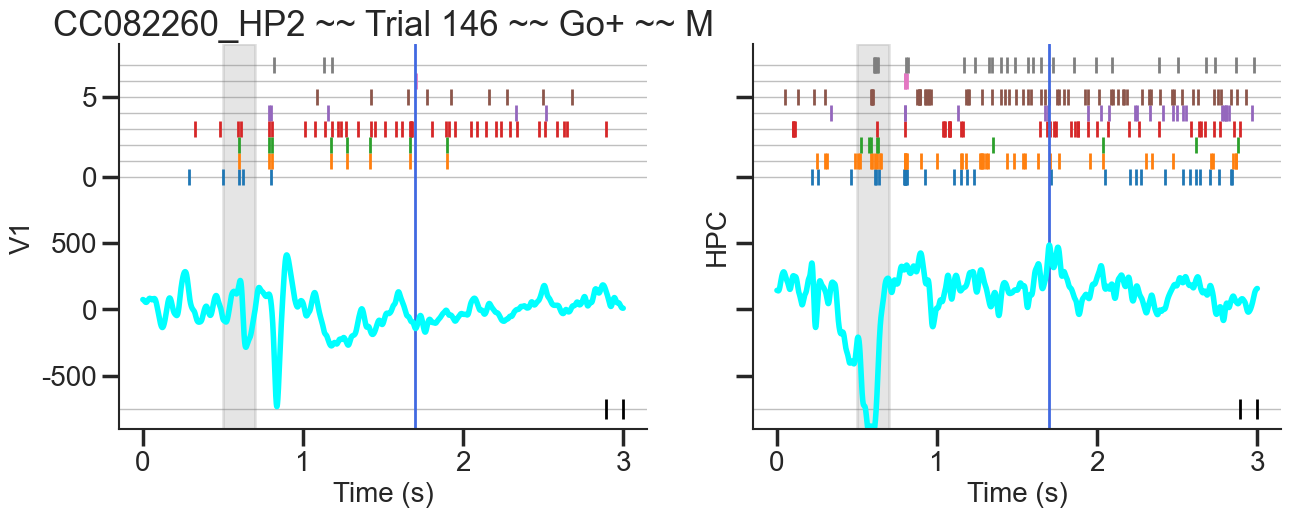

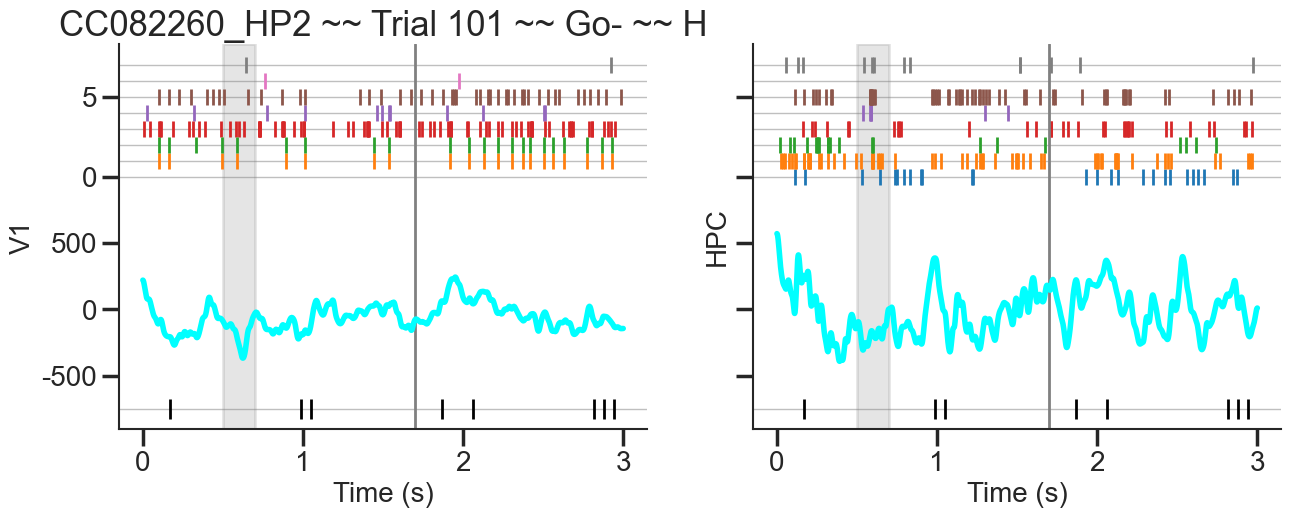

In [123]:
# this is dict with {et: [trial #s]}
d = {'CC082260_HP2':[147,56,124,107,122,30], 'CC082255_HP0':[84,129,51,9,119,78]}
wt_v1_units = ['CC082260_HP2_477', 'CC082260_HP2_544', 'CC082260_HP2_567', 'CC082260_HP2_521', 'CC082260_HP2_517', 
               'CC082260_HP2_548', 'CC082260_HP2_562', 'CC082260_HP2_559']
wt_hpc_units = ['CC082260_HP2_187', 'CC082260_HP2_188', 'CC082260_HP2_201', 'CC082260_HP2_224', 'CC082260_HP2_236',
                'CC082260_HP2_239', 'CC082260_HP2_240', 'CC082260_HP2_254']
fx_v1_units = ['CC082255_HP0_564', 'CC082255_HP0_571', 'CC082255_HP0_589', 'CC082255_HP0_577', 'CC082255_HP0_517', 
               'CC082255_HP0_601', 'CC082255_HP0_554']
fx_hpc_units = ['CC082255_HP0_193', 'CC082255_HP0_212', 'CC082255_HP0_214', 'CC082255_HP0_227', 'CC082255_HP0_259', 
                'CC082255_HP0_263']
unit_gap = 120
rast_start = 1000

is_saving = False

for et,trs in d.items():
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    et_behav = dict(zip(range(150),lfp_fft[(lfp_fft.band=="[4, 8]")&(lfp_fft.et==et)&(lfp_fft.region=='V1')].behav.values))
    et_spk = unit_spikes[unit_spikes.et==et]
    et_spk['behav'] = et_spk['trial'].map(et_behav)
    if et == "CC082260_HP2":
        unit_spk = et_spk[(et_spk.cuid.isin(wt_v1_units))|(et_spk.cuid.isin(wt_hpc_units))] #wt units list for the raster plots
        v1_units, hpc_units = wt_v1_units, wt_hpc_units
    else:
        unit_spk = et_spk[(et_spk.cuid.isin(fx_v1_units))|(et_spk.cuid.isin(fx_hpc_units))]
        v1_units, hpc_units = fx_v1_units, fx_hpc_units
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # for plt_tr in trs:
    for plt_tr in [7, 20, 146, 101]: #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Make this a list of 0-149 to look for another VEP Mis for Go+ and Go-
        dd = all_trial_lfp[(all_trial_lfp.et==et)&(all_trial_lfp.trial==plt_tr)]
        #gets the v1 lfp trace for the et/trial pairing
        tr_stim = dd.stim_id.unique()[0]
        plt_stim = 'Go+' if tr_stim=='0' else ('Go-' if tr_stim=='1' else 'No-Go')
        tr_lfp = dd.lfp_data.values[0]
        v1_lfp = tr_lfp[v1_ch,:]
        hpc_lfp = tr_lfp[hpc_ch,:]
        #trims the behavior df to the et/trial pairing
        tmp0 = behavior[(behavior.et==et)&(behavior.true_tr==plt_tr)&(behavior.lick_time>-0.5)&(behavior.lick_time<2.5)]
        tmp = tmp0['lick_time'].values+0.5 #lick times now zeroed to start of recording
        num_licks = len([x for x in tmp if (x>1.0)&(x<1.7)]) #counting the number of licks within the delay period
        tr_beh = tmp0.behav.unique()[0] if tmp0.size else ('CR' if plt_stim=='No-Go' else 'M') #OR else 'nolick'
        #plot the lfp traces and the licks overlaid
        x_times = np.linspace(0,3,v1_lfp.shape[0])
        plt_color = 'cyan' if dd.group.unique()[0]=='WT' else 'magenta'
        fig,ax = plt.subplots(1,2, sharex=True, sharey=True, figsize=(15,5))
        ax[0].axvspan(0.5,0.7, color='grey', alpha=0.2)
        ax[1].axvspan(0.5,0.7, color='grey', alpha=0.2)
        if plt_stim=='Go+':
            ax[0].axvline(1.7, color='royalblue')
            ax[1].axvline(1.7, color='royalblue')
        elif plt_stim=='Go-':
            ax[0].axvline(1.7, color='grey')
            ax[1].axvline(1.7, color='grey')
        ax[0].plot(x_times, scnd.gaussian_filter1d(v1_lfp, sigma=20), color=plt_color, linewidth=4) #plot gaussian filtered V1 vep
        ax[0].scatter(x=tmp, y=[-750]*len(tmp), marker='|', c='black', s=200) #plot lick raster
        ax[0].axhline(-750, color='grey', linewidth=1, alpha=0.5, zorder=0)
        ax[1].plot(x_times, scnd.gaussian_filter1d(hpc_lfp, sigma=20), color=plt_color, linewidth=4) #plot gaussian filtered V1 vep
        ax[1].scatter(x=tmp, y=[-750]*len(tmp), marker='|', c='black', s=200) #plot lick raster
        ax[1].axhline(-750, color='grey', linewidth=1, alpha=0.5, zorder=0)
        ax[0].set_xlabel('Time (s)')
        ax[1].set_xlabel('Time (s)')
        ax[0].set_ylabel('V1')
        ax[0].set_ylim([-900,(rast_start+unit_gap*5+400)])
        ax[0].set_yticks([-500,0,500,rast_start,(rast_start+unit_gap*5)])
        ax[0].set_yticklabels([-500,0,500,0,5])
        # ax[1].set_ylim([-900,900])
        ax[0].set_title(f"{et} ~~ Trial {plt_tr} ~~ {plt_stim} ~~ {tr_beh}")
        ax[1].set_ylabel('HPC')
        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        #plot the unit rasters (~6 units per region - some don't fire on every trial)
        unit_spk_tr = unit_spk[unit_spk.trial==plt_tr]
        my_pal = sns.color_palette("tab10")
        for idx in range(len(v1_units)):
            ax[0].axhline(rast_start+unit_gap*idx, color='grey', linewidth=1, alpha=0.5, zorder=0)
        for idx in range(len(hpc_units)):
            ax[1].axhline(rast_start+unit_gap*idx, color='grey', linewidth=1, alpha=0.5, zorder=0)
        for u,uu in unit_spk_tr.groupby('cuid'):
            if uu.region.unique()[0]=='v1':
                ax[0].scatter(x=uu.trial_spikes, y=[rast_start+unit_gap*v1_units.index(u)]*len(uu.trial_spikes), marker='|', s=120, color=my_pal[v1_units.index(u)])
            elif uu.region.unique()[0]=='hippo':
                ax[1].scatter(x=uu.trial_spikes, y=[rast_start+unit_gap*hpc_units.index(u)]*len(uu.trial_spikes), marker='|', s=120, color=my_pal[hpc_units.index(u)])
        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        sns.despine()
        if is_saving:
            plt.savefig(rf"C:\Users\AChub_Lab\Desktop\oneEToneTrial_LFPUnitLick_{dd.group.unique()[0]}_tr{plt_tr}_{plt_stim}_{tr_beh}.pdf", transparent=True)
        plt.show()
    break

# ! Spike-Phase coherence

In [68]:
print("LFP dataFrame")
display(all_trial_lfp.head(2))
print("LFP dataFrame to map behavior responses")
display(lfp_fft.head(2))
print("Unit spike time dataFrame")
display(unit_spikes.head(2))
print("Unit psth for visually responsive units")
display(vr_units.head(2))

LFP dataFrame


,et,cc,group,trial,lfp_data,stim_id
0,CC067431_HP2,CC067431,FX,0,"[[125.99329, 120.050354, 137.86186, 156.05075,...",0
1,CC067431_HP2,CC067431,FX,1,"[[-57.64133, -62.18796, -66.814, -47.926105, -...",2


LFP dataFrame to map behavior responses


,trial,band,mean_val,peak_val,auc,et,region,group,stim_id,num_licks,behav
0,0,"[2, 4]",9.128546,11.356609,0.702196,CC067431_HP2,V1,FX,Go+,0,M
1,0,"[4, 8]",4.377809,7.915976,1.034116,CC067431_HP2,V1,FX,Go+,0,M


Unit spike time dataFrame


,cluster_id,spikes,trial,stim_id,trial_spikes,depth,cuid,group,set,region,et,cc,path,behav
0.0,770,0.003133,0.0,0,0.003133,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M
0.0,770,0.044700,0.0,0,0.044700,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M


Unit psth for visually responsive units


,stim_id,times,cuid,depth,Hz,zscore,ztc,region,group,cc,et,r_groups,visRes
0,0,0.00,CC067431_HP2_248,740,2.543532,-0.865956,-2.264451,hippo,FX,CC067431,CC067431_HP2,0,yes
1,0,0.01,CC067431_HP2_248,740,2.918449,-0.811714,-1.841745,hippo,FX,CC067431,CC067431_HP2,0,yes


In [71]:
def butter_bandpass_filter(mydata, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = float(lowcut)/nyq
    high = float(highcut)/nyq
    b, a = ssig.butter(order, [low,high], btype='band')
    y = ssig.filtfilt(b, a, mydata)
    return y

In [72]:
#This cell cuts the unit spike time DataFrame to only include visually responsive units from the vr_psth DataFrame
vr_unit_ls = vr_units.cuid.unique()
vr_unit_spikes = unit_spikes[unit_spikes['cuid'].isin(vr_unit_ls)]

In [91]:
#### THIS SPC LOOKS AT LFP CHANNEL THATS SPECIFIC TO THE UNIT DEPTH

lfp_sr = 2500
unit_sr = 30000
time_win = [0.5, 1.5]
# v1_ch = 260
# hpc_ch = 110

spk_ph_coh_ls, et_num = [], 1
for d,dd in all_trial_lfp.groupby(["et","trial"]):
    #progress bar for looping through ets
    if (d[1]+1)%150==0:
        print(f"Done with {et_num} out of {all_trial_lfp.et.nunique()} mice")
        et_num+=1
    
    #metadata for saving below
    et_group = dd.group.unique()[0]
    tr_stim = 'Go+' if dd.stim_id.unique()[0]=='0' else ('Go-' if dd.stim_id.unique()[0]=='1' else 'No-Go')
    et_behav = lfp_fft[(lfp_fft.et==d[0])&(lfp_fft.trial==d[1])].behav.unique()[0] #this is the et:trial behavior response
    
    # load spikes df, and limit to the specific et
    et_spks = vr_unit_spikes[(vr_unit_spikes.et==d[0])&(vr_unit_spikes.trial==d[1])&(vr_unit_spikes.trial_spikes>=time_win[0])&(vr_unit_spikes.trial_spikes<=time_win[1])] #trim units df to time window
    et_spks_v1hpc = et_spks[(et_spks.region=='v1')|(et_spks.region=='hippo')]
    
    for u,uu in et_spks_v1hpc.groupby('cuid'):
        unit_depth_ch = int(384-(uu.depth.unique()[0])/10)
        my_region = 'V1' if uu.region.unique()[0] == 'v1' else 'HPC'
        tr_lfp = dd.lfp_data.values[0][unit_depth_ch] #pick LFP channel that relates to the unit depth
        filt_lfp = butter_bandpass_filter(tr_lfp, lowcut=4, highcut=8, fs=lfp_sr, order=4) #filter to theta range
        reg_lfp_phase = np.angle(ssig.hilbert(filt_lfp)) #convert to phase domain [-pi, pi]
        u_spk = uu.trial_spikes.values
        unit_phase_ls = []
        my_time = np.linspace(time_win[0],time_win[1],2500)
        for i in range(len(my_time)-1):
            for spk in u_spk:
                if (spk<my_time[i+1])&(spk>=my_time[i]):
                    unit_phase_ls.append(reg_lfp_phase[i])
        u_phs_circm = sstat.circmean(unit_phase_ls, high=np.pi, low=-np.pi)
        spk_ph_coh_ls.append(pd.DataFrame({'trial':[d[1]], 'phase':[u_phs_circm], 'cuid':[u], 'et':[d[0]], 
                                           'group':[et_group], 'region':[my_region], 'stim_id':[tr_stim], 'behav':[et_behav]}))
spk_ph_coh = pd.concat(spk_ph_coh_ls, ignore_index=True)
spk_ph_coh.head()

Done with 1 out of 18 mice
Done with 2 out of 18 mice
Done with 3 out of 18 mice
Done with 4 out of 18 mice
Done with 5 out of 18 mice
Done with 6 out of 18 mice
Done with 7 out of 18 mice
Done with 8 out of 18 mice
Done with 9 out of 18 mice
Done with 10 out of 18 mice
Done with 11 out of 18 mice
Done with 12 out of 18 mice
Done with 13 out of 18 mice
Done with 14 out of 18 mice
Done with 15 out of 18 mice
Done with 16 out of 18 mice
Done with 17 out of 18 mice
Done with 18 out of 18 mice


,trial,phase,cuid,et,group,region,stim_id,behav
0,0,-0.117251,CC067431_HP2_198,CC067431_HP2,FX,HPC,Go+,M
1,0,-2.370311,CC067431_HP2_200,CC067431_HP2,FX,HPC,Go+,M
2,0,1.629177,CC067431_HP2_204,CC067431_HP2,FX,HPC,Go+,M
3,0,2.020597,CC067431_HP2_205,CC067431_HP2,FX,HPC,Go+,M
4,0,-3.018792,CC067431_HP2_213,CC067431_HP2,FX,HPC,Go+,M


In [98]:
#takes the circular mean of each unit, split by stim_id and behavior
spk_ph_coh_mean = []
for d,dd in spk_ph_coh.groupby(['cuid','stim_id','behav']):
    mean_phs_circm = sstat.circmean(dd.phase.values, high=np.pi, low=-np.pi)
    spk_ph_coh_mean.append(pd.DataFrame({'mean_phase':[mean_phs_circm], 'cuid':[d[0]], 'et':dd.et.unique()[0], 
                                         'group':dd.group.unique()[0], 'region':dd.region.unique()[0], 'stim_id':[d[1]], 'behav':[d[2]]}))
spk_ph_coh_mean = pd.concat(spk_ph_coh_mean, ignore_index=True)
spk_ph_coh_mean.head()

,mean_phase,cuid,et,group,region,stim_id,behav
0,0.301214,CC067431_HP2_189,CC067431_HP2,FX,HPC,Go+,M
1,-0.928363,CC067431_HP2_189,CC067431_HP2,FX,HPC,Go-,H
2,2.739106,CC067431_HP2_189,CC067431_HP2,FX,HPC,Go-,M
3,0.155420,CC067431_HP2_189,CC067431_HP2,FX,HPC,No-Go,CR
4,-0.583315,CC067431_HP2_189,CC067431_HP2,FX,HPC,No-Go,FA


2-sided KS test comparing the distributions of WT & FX
Go+ ('HPC', 'H') -- N: WT=582, FX=418 -- p=0.5251293691501057 -- ns
Go+ ('HPC', 'M') -- N: WT=591, FX=580 -- p=0.8385659817668188 -- ns
Go+ ('V1', 'H') -- N: WT=736, FX=465 -- p=0.578671040095661 -- ns
Go+ ('V1', 'M') -- N: WT=793, FX=648 -- p=0.5677244122723437 -- ns


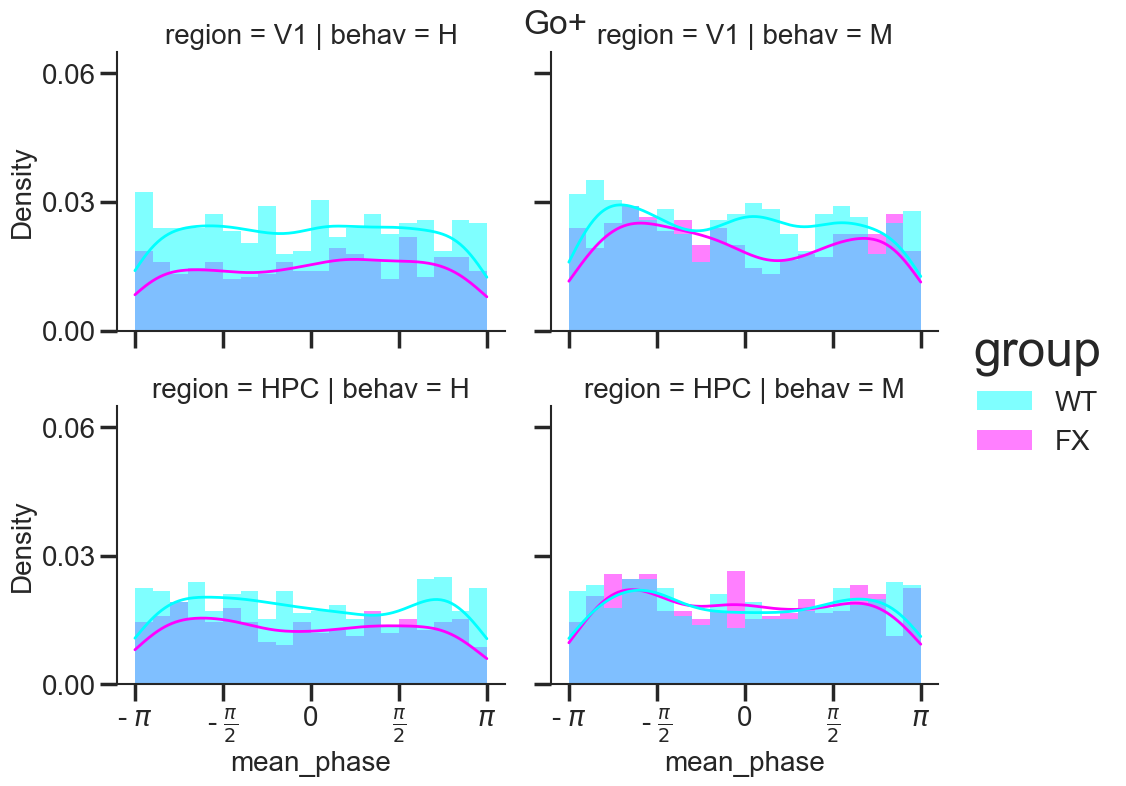

2-sided KS test comparing the distributions of WT & FX
Go- ('HPC', 'H') -- N: WT=548, FX=375 -- p=0.4318803698189815 -- ns
Go- ('HPC', 'M') -- N: WT=502, FX=558 -- p=0.963939271259849 -- ns
Go- ('V1', 'H') -- N: WT=671, FX=404 -- p=0.13528659825018977 -- ns
Go- ('V1', 'M') -- N: WT=647, FX=624 -- p=0.0017782933664765655 -- **


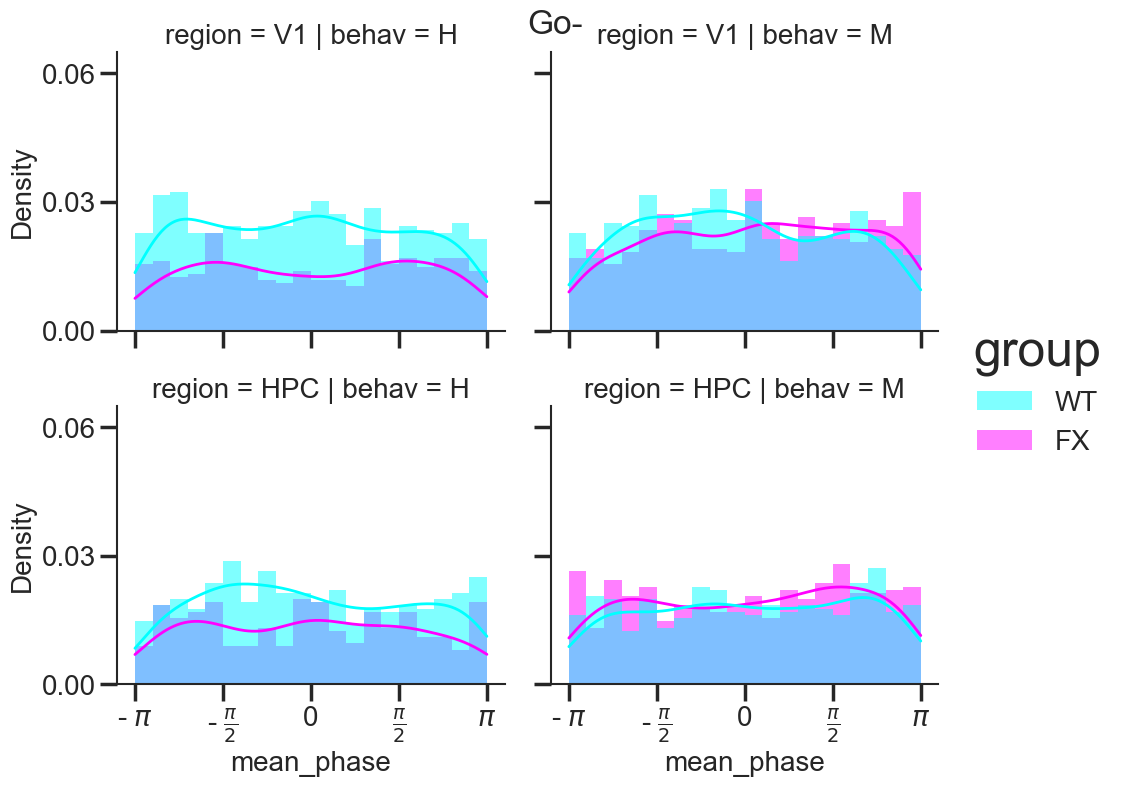

2-sided KS test comparing the distributions of WT & FX
No-Go ('HPC', 'CR') -- N: WT=633, FX=587 -- p=0.9460587858356371 -- ns
No-Go ('HPC', 'FA') -- N: WT=569, FX=449 -- p=0.5014964685831347 -- ns
No-Go ('V1', 'CR') -- N: WT=811, FX=654 -- p=0.4381951415819045 -- ns
No-Go ('V1', 'FA') -- N: WT=728, FX=487 -- p=0.3921364740120254 -- ns


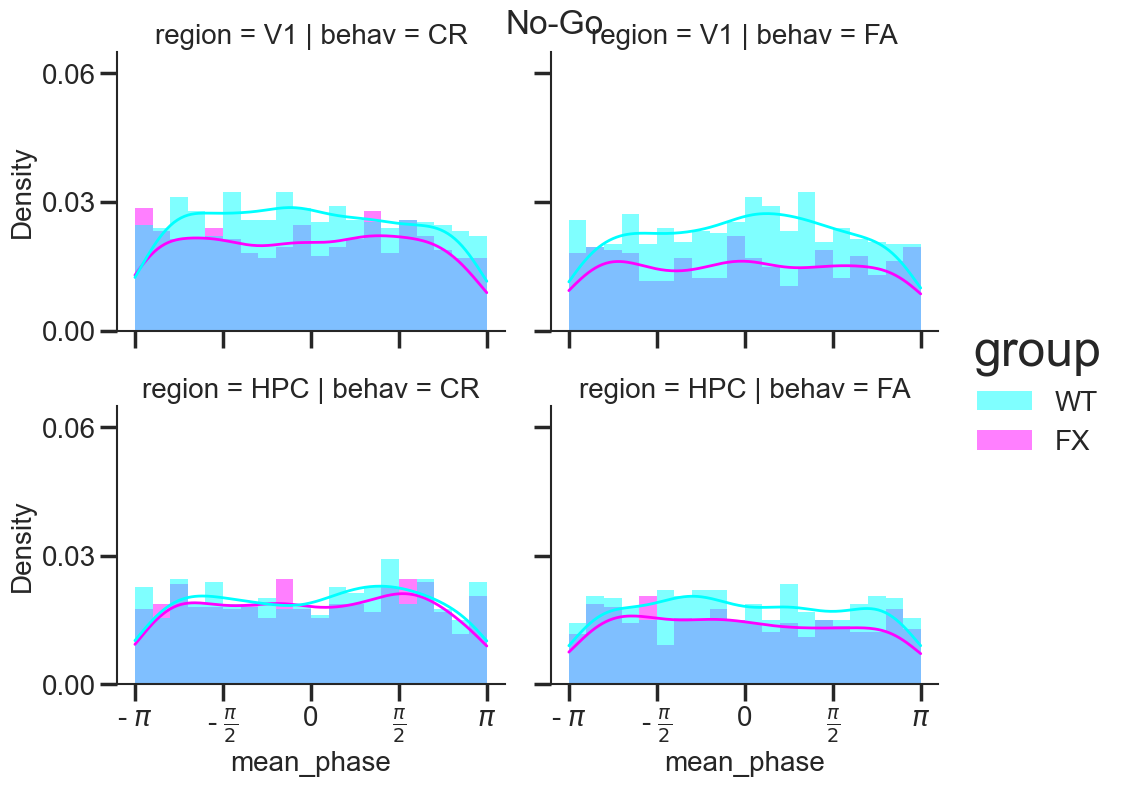

In [99]:
for d,dd in spk_ph_coh_mean.groupby('stim_id'):
    g=sns.displot(data=dd, x='mean_phase', col='behav', col_order=['CR', 'FA'] if d=='No-Go' else ['H', 'M'], row='region', row_order=['V1', 'HPC'],
                hue='group', hue_order=['WT','FX'], palette={'WT':'cyan', 'FX':'magenta'},
                kde=True, rug=False, stat='density', binwidth=(np.pi/10), height=4, aspect=1.25, linewidth=0)
    plt.suptitle(d)
    g.set(xticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi], yticks=[0, 0.03, 0.06], ylim=[0,0.065])
    g.set_xticklabels([r'- $\pi$',r'- $\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$', r'$\pi$'])
    print("2-sided KS test comparing the distributions of WT & FX")
    for e,ee in dd.groupby(['region','behav']):
        x,y = ee[ee.group=='WT']['mean_phase'].values, ee[ee.group=='FX']['mean_phase'].values # N = #units
        res = sstat.ks_2samp(x,y)
        plt_stats = "***" if res.pvalue < 0.001 else ("**" if res.pvalue<0.01 else ("*" if res.pvalue <0.05 else "ns"))
        print(f"{d} {e} -- N: WT={len(x)}, FX={len(y)} -- p={res.pvalue} --", plt_stats)
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\Spike_phase_coherence\SPC_GenotypeSplit_histogram_{d}.pdf", transparent=True)
    plt.show()

2-sided KS test comparing the distributions of behav within genotype
Go+ ('HPC', 'FX') -- N: H/CR=418, M/FA=580 -- p=0.9426288901785342 -- ns
Go+ ('HPC', 'WT') -- N: H/CR=582, M/FA=591 -- p=0.925326783483214 -- ns
Go+ ('V1', 'FX') -- N: H/CR=465, M/FA=648 -- p=0.02962496320409159 -- *
Go+ ('V1', 'WT') -- N: H/CR=736, M/FA=793 -- p=0.6075319464142216 -- ns


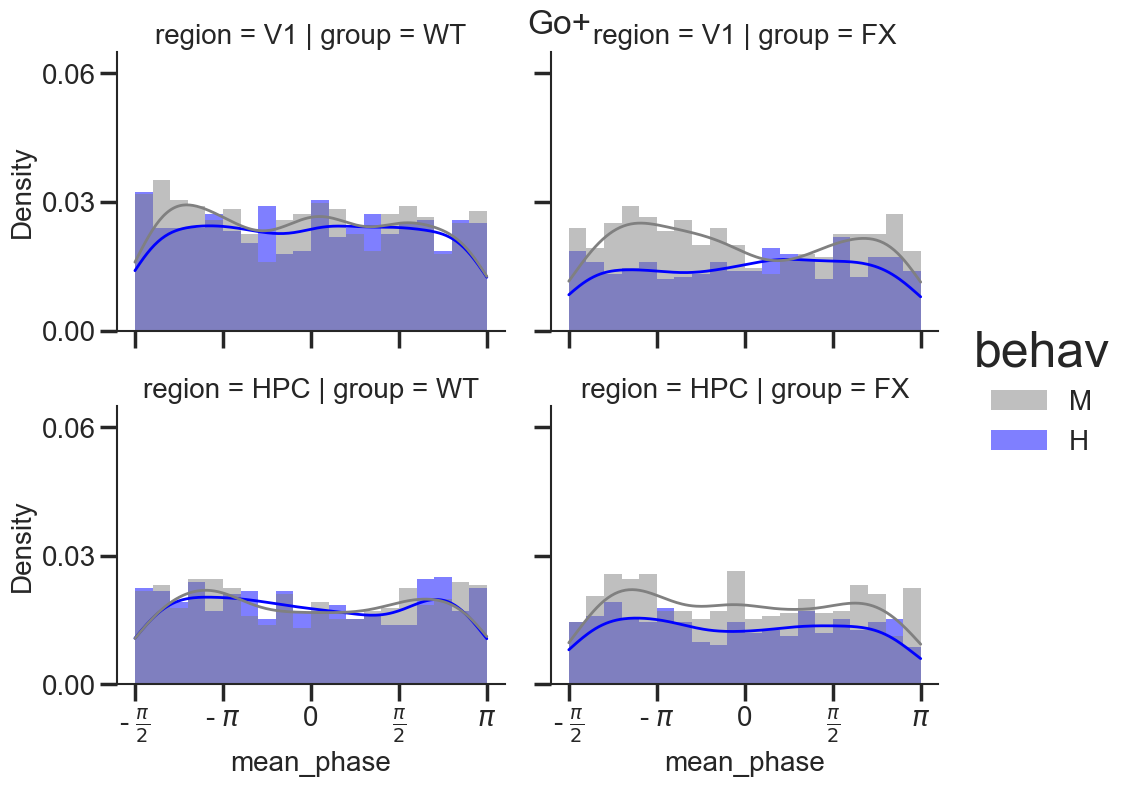

2-sided KS test comparing the distributions of behav within genotype
Go- ('HPC', 'FX') -- N: H/CR=375, M/FA=558 -- p=0.29940182362580403 -- ns
Go- ('HPC', 'WT') -- N: H/CR=548, M/FA=502 -- p=0.3866036579139175 -- ns
Go- ('V1', 'FX') -- N: H/CR=404, M/FA=624 -- p=0.14230307506484863 -- ns
Go- ('V1', 'WT') -- N: H/CR=671, M/FA=647 -- p=0.376134946538873 -- ns


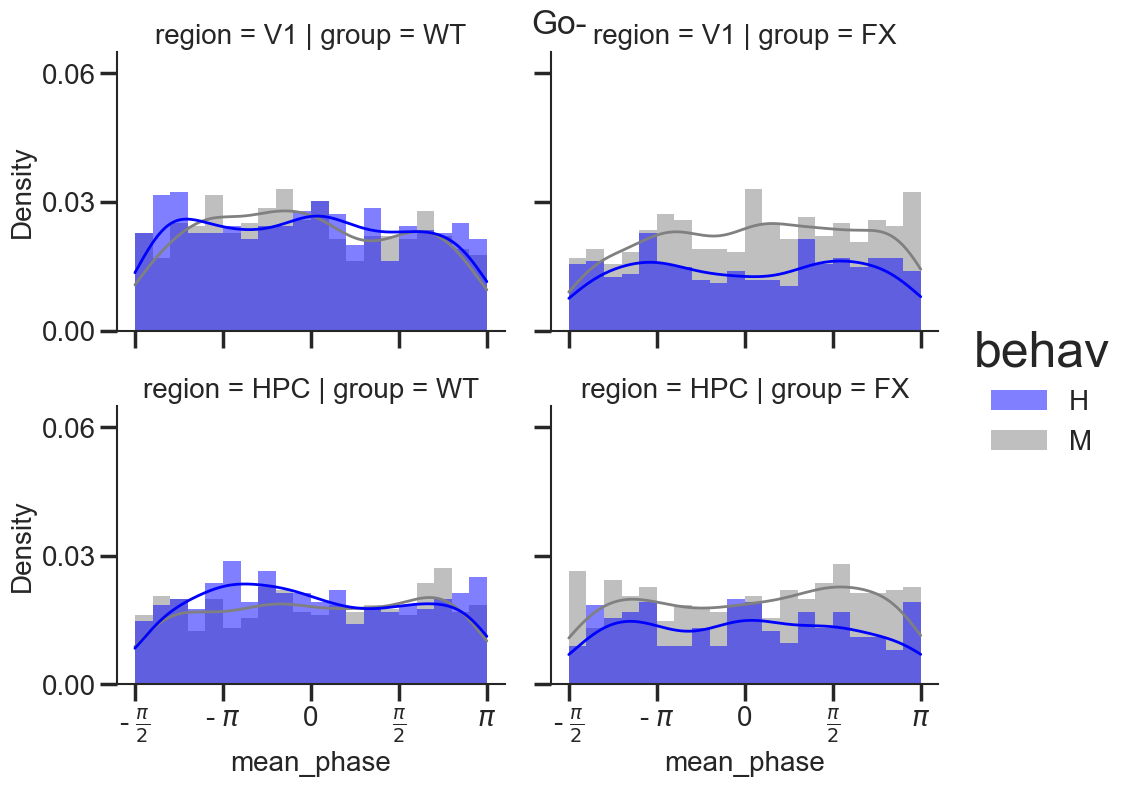

2-sided KS test comparing the distributions of behav within genotype
No-Go ('HPC', 'FX') -- N: H/CR=587, M/FA=449 -- p=0.5155896248673218 -- ns
No-Go ('HPC', 'WT') -- N: H/CR=633, M/FA=569 -- p=0.428267324707822 -- ns
No-Go ('V1', 'FX') -- N: H/CR=654, M/FA=487 -- p=0.7761614413112127 -- ns
No-Go ('V1', 'WT') -- N: H/CR=811, M/FA=728 -- p=0.5755989634165685 -- ns


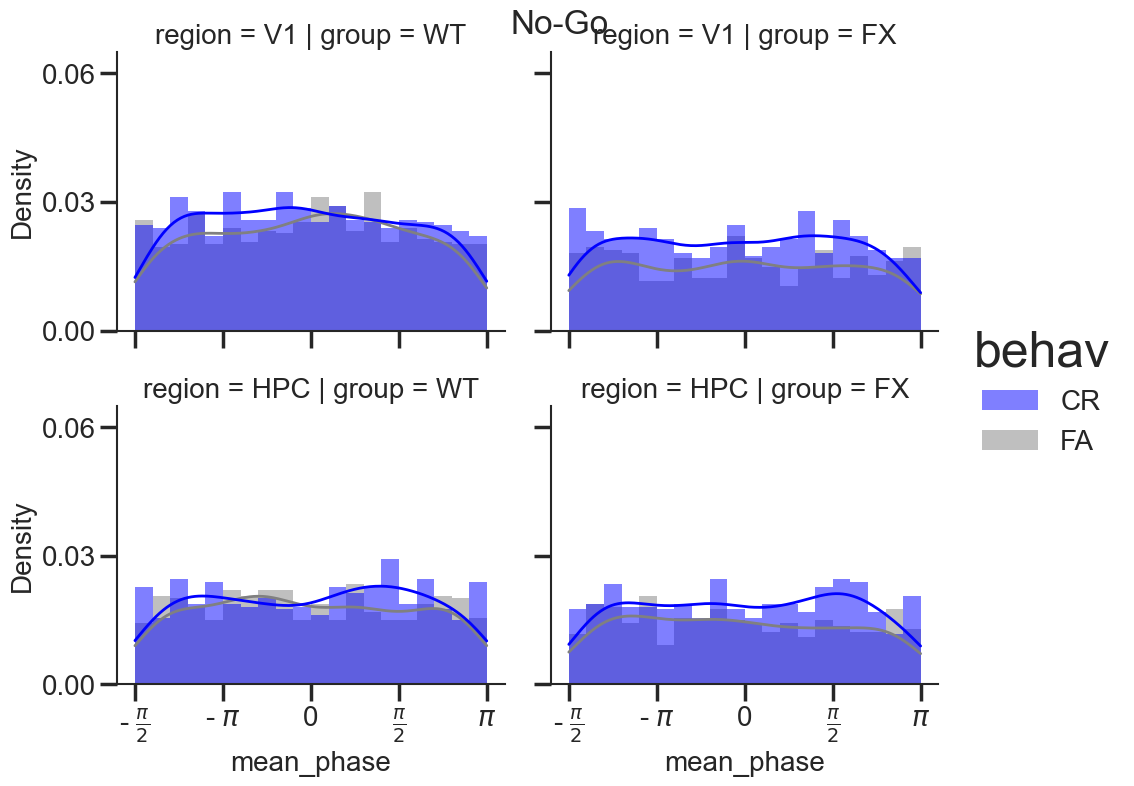

In [100]:
for d,dd in spk_ph_coh_mean.groupby('stim_id'):
    g=sns.displot(data=dd, x='mean_phase', col='group', col_order=['WT','FX'], row='region', row_order=['V1', 'HPC'],
                hue='behav', palette={'H':'blue', 'M':'grey', 'CR':'blue', 'FA':'grey'},
                kde=True, rug=False, stat='density', binwidth=(np.pi/10), height=4, aspect=1.25, linewidth=0)
    plt.suptitle(d)
    g.set(xticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi], yticks=[0, 0.03, 0.06], ylim=[0,0.065])
    g.set_xticklabels([r'- $\frac{\pi}{2}$', r'- $\pi$', '0', r'$\frac{\pi}{2}$', r'$\pi$'])
    print("2-sided KS test comparing the distributions of behav within genotype")
    for e,ee in dd.groupby(['region','group']):
        if d == 'No-Go':
            x,y = ee[ee.behav=='CR']['mean_phase'].values, ee[ee.behav=='FA']['mean_phase'].values # N = #units
        else:
            x,y = ee[ee.behav=='H']['mean_phase'].values, ee[ee.behav=='M']['mean_phase'].values # N = #units
        res = sstat.ks_2samp(x,y)
        plt_stats = "***" if res.pvalue < 0.001 else ("**" if res.pvalue<0.01 else ("*" if res.pvalue <0.05 else "ns"))
        print(f"{d} {e} -- N: H/CR={len(x)}, M/FA={len(y)} -- p={res.pvalue} --", plt_stats)
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\temp_figures\Spike_phase_coherence\SPC_BehaviorSplit_histogram_{d}.pdf", transparent=True)
    plt.show()

# ! Aside, more unit analysis
This is an aside for the above cells. I'm working on making a 2d plot for the unit responses split by behavior

## PSTH dataframe creation

In [352]:
print("LFP dataFrame to map behavior responses")
display(lfp_fft.head(2))
print("Unit spike time dataFrame")
display(unit_spikes.head(2))
print("Unit psth (no behavior) used to id visually responsize units")
display(vr_units.head(2))

LFP dataFrame to map behavior responses


,trial,band,mean_val,peak_val,auc,et,region,group,stim_id,num_licks,behav
0,0,"[2, 4]",9.128546,11.356609,0.702196,CC067431_HP2,V1,FX,Go+,0,M
1,0,"[4, 8]",4.377809,7.915976,1.034116,CC067431_HP2,V1,FX,Go+,0,M


Unit spike time dataFrame


,cluster_id,spikes,trial,stim_id,trial_spikes,depth,cuid,group,set,region,et,cc,path
0.0,770,0.003133,0.0,0,0.003133,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...
0.0,770,0.044700,0.0,0,0.044700,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...


Unit psth (no behavior) used to id visually responsize units


,stim_id,times,cuid,depth,Hz,zscore,ztc,region,group,cc,et,r_groups,visRes
0,0,0.00,CC067431_HP2_248,740,2.543532,-0.865956,-2.264451,hippo,FX,CC067431,CC067431_HP2,0,yes
1,0,0.01,CC067431_HP2_248,740,2.918449,-0.811714,-1.841745,hippo,FX,CC067431,CC067431_HP2,0,yes


In [353]:
et_trl_behav_dict = {}
for t,tt in lfp_fft.groupby('et'):
    inner = {}
    for m,mm in tt.groupby('trial'):
        inner.update({m:mm.behav.unique()[0]})
    et_trl_behav_dict.update({t:inner})
# print(et_trl_behav_dict)

In [354]:
for t,tt in enumerate(unit_spikes.et.unique()):
    unit_spikes.loc[(unit_spikes.et==tt), 'behav'] = unit_spikes[unit_spikes.et==tt].trial.map(et_trl_behav_dict[tt])
unit_spikes.head()

,cluster_id,spikes,trial,stim_id,trial_spikes,depth,cuid,group,set,region,et,cc,path,behav
0.0,770,0.003133,0.0,0,0.003133,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M
0.0,770,0.044700,0.0,0,0.044700,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M
0.0,770,0.120567,0.0,0,0.120567,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M
0.0,770,0.170067,0.0,0,0.170067,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M
0.0,770,0.236600,0.0,0,0.236600,3620,CC067431_HP2_770,B,1,none,CC067431_HP2,CC067431,G:\Neuropixels\interval_operant_training\opera...,M


In [355]:
#This cell cuts the unit spike time DataFrame to only include visually responsive units from the vr_psth DataFrame
#also only includes units that are in V1 or HPC
vr_unit_ls = vr_units.cuid.unique()
region_ls = ['v1','hippo']
vr_unit_spikes = unit_spikes[(unit_spikes['cuid'].isin(vr_unit_ls))&(unit_spikes['region'].isin(region_ls))]

In [364]:
ls_psth = []
th_bin = 0.01
trial_length = 3.0

num_units, un_idx = vr_unit_spikes['cuid'].nunique(), 0
for l,ll in vr_unit_spikes.groupby(['cuid', 'stim_id', 'behav']): ##### I changed this from df_rez to data_df to check the units
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    trials_number_not_empty = len(ll.trial.unique())    
    h, ttr = mz_ena.PSTH(ll.trial_spikes, th_bin, trial_length, trials_number_not_empty)
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    zscore = sstat.mstats.zscore(h)
    mean = np.mean(h[0:50])#The Baseline period. Be sure it matches time course of experiments##
    std = 1 if mean<=0 else np.std(h[0:50])
    ztc = (h - mean)/std
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    tr_stim = 'Go+' if l[1]==0 else ('Go-' if l[1]==1 else 'No-Go')
    my_region = 'V1' if ll.region.unique()[0] == 'v1' else 'HPC'
    tr_group = 'WT' if ll.group.unique()[0] == "A" else "FX"
    df_psth_tmp = pd.DataFrame({'times':ttr, 'stim_id':tr_stim, 'Hz':h, 'depth':ll.depth.unique()[0],
                                'zscore':zscore, 'ztc':ztc, 'et':ll.et.unique()[0], 'cc': ll.cc.unique()[0],
                                'cuid':l[0], 'region':my_region, 'group':tr_group, 'behav':l[2]})
    ls_psth.append(df_psth_tmp)
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
behav_psth = pd.concat(ls_psth)
behav_psth.head()

,times,stim_id,Hz,depth,zscore,ztc,et,cc,cuid,region,group,behav
0,0.00,Go+,0.0,620,-0.348372,-0.693389,CC067431_HP2,CC067431,CC067431_HP2_189,HPC,FX,H
1,0.01,Go+,0.0,620,-0.348372,-0.693389,CC067431_HP2,CC067431,CC067431_HP2_189,HPC,FX,H
2,0.02,Go+,0.0,620,-0.348372,-0.693389,CC067431_HP2,CC067431,CC067431_HP2_189,HPC,FX,H
3,0.03,Go+,0.0,620,-0.348372,-0.693389,CC067431_HP2,CC067431,CC067431_HP2_189,HPC,FX,H
4,0.04,Go+,0.0,620,-0.348372,-0.693389,CC067431_HP2,CC067431,CC067431_HP2_189,HPC,FX,H


## Power Spectrum Analysis, unit activity, split by behavior

In [365]:
def get_unit_fft(unit_df):
    unit_arr = unit_df[(unit_df.times>0.5)&(unit_df.times<1.8)].zscore.values
    freq = np.arange(unit_arr.shape[0]) / unit_arr.shape[0] * 100
    freq = freq[:freq.shape[0]//2]
    f = np.fft.fft(unit_arr)
    magnitude_spectrum = (np.abs(f)[:freq.shape[0]])
    return freq, magnitude_spectrum

In [389]:
behav_units_fft = []
for unit,df in behav_psth.groupby(['stim_id','behav','cuid']):
    fft_freq, fft_amp = get_unit_fft(df)
    bands = [[4,8]] 
    auc_val,band_val = [],[]
    for ran in bands:
        lower = fft_freq.searchsorted(ran[0], 'left')
        upper = fft_freq.searchsorted(ran[1], 'right') -1
        val = auc(fft_freq[lower:upper],fft_amp[lower:upper])
        auc_val.append(val)
        band_val.append(str(ran))
    behav_units_fft.append(pd.DataFrame({'band': band_val, 'auc': auc_val, 'cuid': unit[-1], 
                                         'stim_id': unit[0], 'group': df.group.unique()[0], 'behav':unit[1],
                                         'region': df.region.unique()[0], 'et': df.et.unique()[0]}))
behav_units_fft = pd.concat(behav_units_fft, ignore_index=True)
behav_units_fft.head()

,band,auc,cuid,stim_id,group,behav,region,et
0,"[4, 8]",1.032766e-15,CC067431_HP2_189,Go+,FX,H,HPC,CC067431_HP2
1,"[4, 8]",2.248598e+01,CC067431_HP2_191,Go+,FX,H,HPC,CC067431_HP2
2,"[4, 8]",1.455019e+01,CC067431_HP2_193,Go+,FX,H,HPC,CC067431_HP2
3,"[4, 8]",2.399450e+01,CC067431_HP2_198,Go+,FX,H,HPC,CC067431_HP2
4,"[4, 8]",1.493351e+01,CC067431_HP2_200,Go+,FX,H,HPC,CC067431_HP2


In [452]:
# this is finding the threshold for each group/stim_id pairing to threshold units in cell below

num_std = 1.0

nested_dict={}
for d,dd in behav_units_fft.groupby('group'):
    nested_dict[d] = {}
    for stim in ["Go", "No-Go"]:
        ee = dd[dd.stim_id!="No-Go"] if stim=="Go" else dd[dd.stim_id=="No-Go"]
        thresh = ee.auc.values.mean()+num_std*ee.auc.values.std() # threshold of mean + 1 std.
        nested_dict[d][stim] = thresh
nested_dict

{'FX': {'Go': 36.21745468695539, 'No-Go': 33.17066808868208},
 'WT': {'Go': 37.4525030574999, 'No-Go': 34.72243505322288}}

In [453]:
unit_thresh_dict = {}
for stim in ["Go", "No-Go"]:
    temp_df = behav_units_fft[behav_units_fft.stim_id!="No-Go"] if stim=="Go" else behav_units_fft[behav_units_fft.stim_id=="No-Go"]
    unit_thresh_dict[stim] = {}
    for d,dd in temp_df.groupby(['group','cuid']):
        thresh = nested_dict[d[0]][stim]
        unit_thresh_dict[stim][d[1]] = 'yes' if dd.auc.values.mean() >= thresh else 'no'
# print(unit_thresh_dict)

In [454]:
# Function to categorize values
def categorize(value):
    if value == 'No-Go':
        return 'No-Go'
    else:
        return 'Go'

behav_units_fft['stim_id2'] = behav_units_fft['stim_id'].apply(categorize)

behav_units_fft['thresh'] = behav_units_fft.apply(lambda x: unit_thresh_dict[x['stim_id2']][x['cuid']], axis=1) #map the nexted dictionary to the stim/cuid pairing
behav_units_fft.head()

,band,auc,cuid,stim_id,group,behav,region,et,stim_id2,thresh
0,"[4, 8]",1.032766e-15,CC067431_HP2_189,Go+,FX,H,HPC,CC067431_HP2,Go,no
1,"[4, 8]",2.248598e+01,CC067431_HP2_191,Go+,FX,H,HPC,CC067431_HP2,Go,no
2,"[4, 8]",1.455019e+01,CC067431_HP2_193,Go+,FX,H,HPC,CC067431_HP2,Go,no
3,"[4, 8]",2.399450e+01,CC067431_HP2_198,Go+,FX,H,HPC,CC067431_HP2,Go,no
4,"[4, 8]",1.493351e+01,CC067431_HP2_200,Go+,FX,H,HPC,CC067431_HP2,Go,no


~~~~~~~~~~ comparing behavior conditions within each group ~~~~~~~~~~
('HPC', 'FX') -- MannwhitneyuResult(statistic=3196.0, pvalue=0.542076520371678) -- ns
('HPC', 'WT') -- MannwhitneyuResult(statistic=3154.0, pvalue=0.4180130862627015) -- ns
('V1', 'FX') -- MannwhitneyuResult(statistic=9613.0, pvalue=2.4621632996050192e-05) -- ***
('V1', 'WT') -- MannwhitneyuResult(statistic=20838.0, pvalue=0.0051058444110779365) -- **
~~~~~~~~~~ comparing groups within each behavior condition ~~~~~~~~~~
('HPC', 'H') -- MannwhitneyuResult(statistic=2437.0, pvalue=0.06244770777036479) -- ns
('HPC', 'M') -- MannwhitneyuResult(statistic=2589.0, pvalue=0.00411109670282559) -- **
('V1', 'H') -- MannwhitneyuResult(statistic=6806.0, pvalue=0.27725096202232413) -- ns
('V1', 'M') -- MannwhitneyuResult(statistic=14974.0, pvalue=0.015669789077757477) -- *


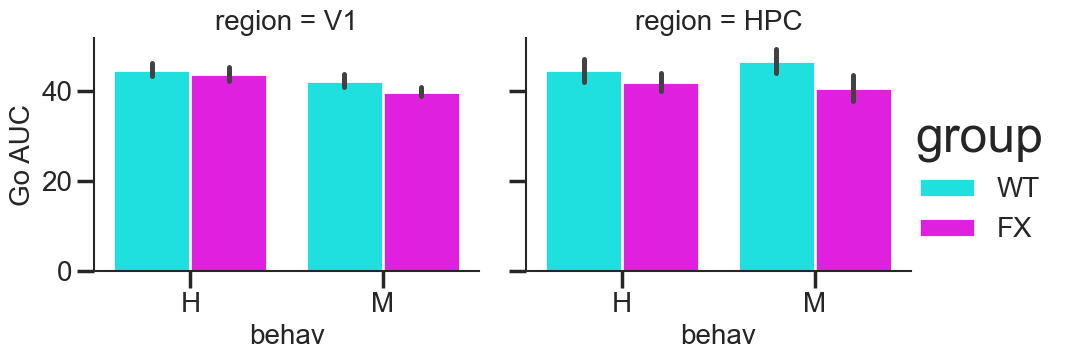

~~~~~~~~~~ comparing behavior conditions within each group ~~~~~~~~~~
('HPC', 'FX') -- MannwhitneyuResult(statistic=1409.0, pvalue=0.5402369939493783) -- ns
('HPC', 'WT') -- MannwhitneyuResult(statistic=2433.0, pvalue=0.09377501541069445) -- ns
('V1', 'FX') -- MannwhitneyuResult(statistic=2957.0, pvalue=0.5412844253745958) -- ns
('V1', 'WT') -- MannwhitneyuResult(statistic=4937.0, pvalue=0.7671797305464805) -- ns
~~~~~~~~~~ comparing groups within each behavior condition ~~~~~~~~~~
('HPC', 'CR') -- MannwhitneyuResult(statistic=1163.0, pvalue=0.0002962710811466648) -- ***
('HPC', 'FA') -- MannwhitneyuResult(statistic=1060.5, pvalue=0.015394512810134209) -- *
('V1', 'CR') -- MannwhitneyuResult(statistic=4187.0, pvalue=0.47864991345180663) -- ns
('V1', 'FA') -- MannwhitneyuResult(statistic=2720.0, pvalue=0.12134697159398342) -- ns


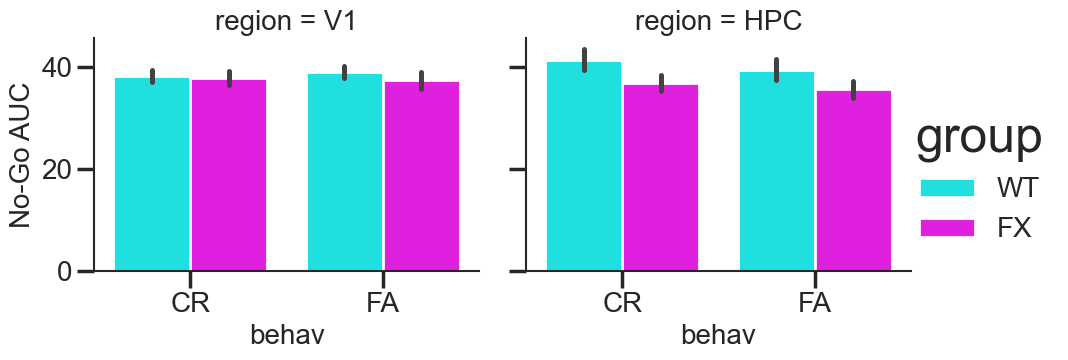

In [455]:
for d,dd in behav_units_fft[behav_units_fft.thresh=='yes'].groupby('stim_id2'):
    print("~~~~~~~~~~ comparing behavior conditions within each group ~~~~~~~~~~")
    for e,ee in dd.groupby(['region', 'group']):
        conds = ee.behav.unique()
        x=ee[ee.behav==conds[0]].auc.values
        y=ee[ee.behav==conds[1]].auc.values
        res = sstat.mannwhitneyu(x, y)
        pstar = '***' if res.pvalue < 0.001 else ('**' if res.pvalue < 0.01 else ('*' if res.pvalue < 0.05 else "ns"))
        print(f"{e} -- {res} -- {pstar}")
    print("~~~~~~~~~~ comparing groups within each behavior condition ~~~~~~~~~~")
    for e,ee in dd.groupby(['region', 'behav']):
        conds = ee.group.unique()
        x=ee[ee.group==conds[0]].auc.values
        y=ee[ee.group==conds[1]].auc.values
        res = sstat.mannwhitneyu(x, y)
        pstar = '***' if res.pvalue < 0.001 else ('**' if res.pvalue < 0.01 else ('*' if res.pvalue < 0.05 else "ns"))
        print(f"{e} -- {res} -- {pstar}")
        
    g = sns.catplot(dd, kind="bar", 
                x="behav", y="auc", hue='group', hue_order=['WT','FX'],
                col='region', col_order=['V1', 'HPC'], 
                height=4, aspect=1.2)
    g.set_ylabels(f"{d} AUC")
    plt.show()

## Plot it

In [66]:
osc_characteristic = 'auc'
unit_evidence = []
for d,dd in behav_units_fft[(behav_units_fft.et.isin(active_ets))].groupby(['et','region']):
    go_c = dd[(dd.stim_id=='Go+')&(dd.behav=='H')|(dd.stim_id=='Go-')&(dd.behav=='H')][osc_characteristic].mean()
    go_i = dd[(dd.stim_id=='Go+')&(dd.behav=='M')|(dd.stim_id=='Go-')&(dd.behav=='M')][osc_characteristic].mean()
    go_all = dd[(dd.stim_id=='Go+')|(dd.stim_id=='Go-')][osc_characteristic].mean()
    ng_c = dd[(dd.stim_id=='No-Go')&(dd.behav=='CR')][osc_characteristic].mean()
    ng_i = dd[(dd.stim_id=='No-Go')&(dd.behav=='FA')][osc_characteristic].mean()
    ng_all = dd[dd.stim_id=='No-Go'][osc_characteristic].mean()
    go = (go_c-go_i)/(go_c+go_i)
    ng = (ng_c-ng_i)/(ng_c+ng_i)
    g_ng = (go-ng)/(go+ng)
    go_base = (go_c-go_all)/(dd[(dd.stim_id=='Go+')|(dd.stim_id=='Go-')][osc_characteristic].std())
    ng_base = (ng_c-ng_all)/(dd[dd.stim_id=='No-Go'][osc_characteristic].std())

    foo = lfp_fft[(lfp_fft.et==d[0])&(lfp_fft.region==d[-1])]
    lick_dict = foo.groupby('behav').trial.nunique().to_dict()
    
    d_prime = sstat.norm.ppf(lick_dict['H']/100) - sstat.norm.ppf(lick_dict['FA']/50)
    unit_evidence.append(pd.DataFrame({'goC':go_c, 'goIC':go_i,'ngC':ng_c, 'ngIC':ng_i,'go_avg':go, 'ng_avg':ng, 'gng_avg':g_ng, 'go_base':go_base, 'ng_base':ng_base,
                                       'go_licks':lick_dict['H']/100, 'ng_licks':lick_dict['CR']/50, 'gng_licks':(lick_dict['H']+lick_dict['CR'])/150, 'Dprime':d_prime, 
                                       'go2_licks':lick_dict['M']/100, 'ng2_licks':lick_dict['FA']/50,
                                       'et':d[0], 'group':dd.group.unique()[0], 'region':d[-1]}, index=[0]))
unit_evidence = pd.concat(unit_evidence, ignore_index=True)
unit_evidence.head()

,goC,goIC,ngC,ngIC,go_avg,ng_avg,gng_avg,go_base,ng_base,go_licks,ng_licks,gng_licks,Dprime,go2_licks,ng2_licks,et,group,region
0,26.052272,20.005870,22.962565,23.258597,0.131278,-0.006405,1.102579,0.273144,-0.017749,0.07,0.88,0.340000,-0.300804,0.93,0.12,CC067431_HP2,FX,HPC
1,23.721562,23.998327,21.776109,21.150176,-0.005800,0.014582,-2.320861,-0.012827,0.034973,0.07,0.88,0.340000,-0.300804,0.93,0.12,CC067431_HP2,FX,V1
2,25.183447,25.499678,26.406791,23.451373,-0.006239,0.059277,-1.235283,-0.014038,0.124940,0.05,0.98,0.360000,0.408895,0.95,0.02,CC067432_HP3,FX,HPC
3,23.115990,26.858543,27.315433,19.255385,-0.074889,0.173071,-2.525525,-0.172780,0.282879,0.05,0.98,0.360000,0.408895,0.95,0.02,CC067432_HP3,FX,V1
4,31.358975,27.313993,25.392810,27.154180,0.068941,-0.033520,2.892644,0.158585,-0.100875,0.55,0.56,0.553333,0.276631,0.45,0.44,CC067432_HP4,FX,HPC


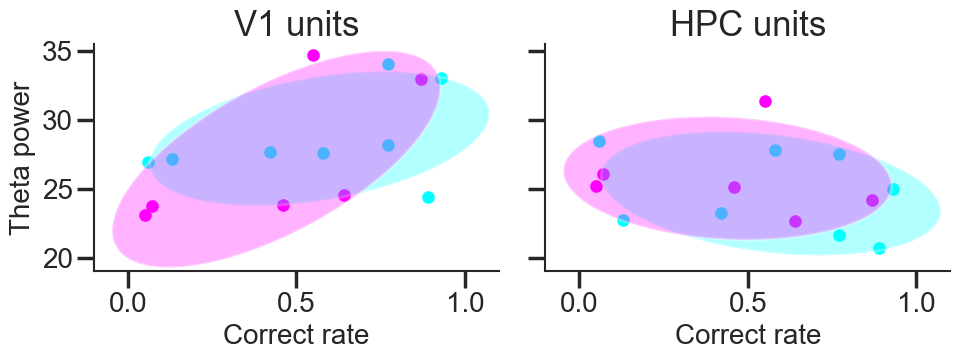

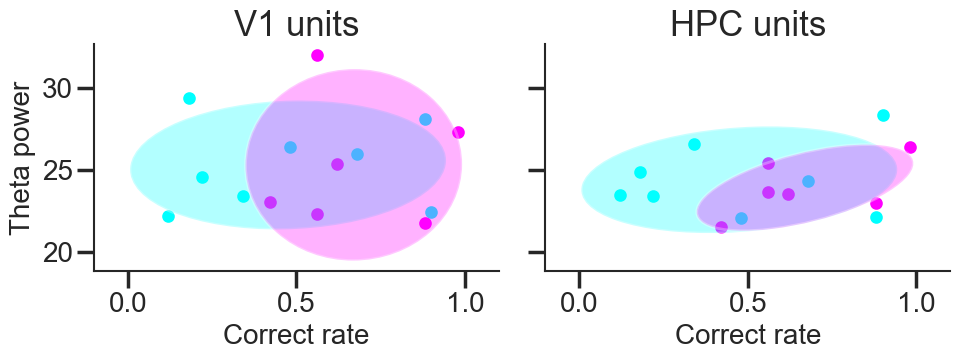

In [81]:
dot_size = 50 # 50, aesthetic choice for the size of the scatter plot dots
plot_linReg = False # adds a linear regression to the 2d scatter
plot_ell = True #adds the covariance confidence ellipse to the data
num_std = 1.5 # standard deviation you want to have contained within the ellipse

# for val in [['go_licks', 'go_base'], ['ng_licks', 'ng_base']]:
# for val in [['go_licks', 'go_avg'], ['ng_licks', 'ng_avg']]:#, ['gng_licks', 'gng_avg'], ['Dprime', 'gng_avg']]:

for val in [['go_licks', 'goC'], ['ng_licks', 'ngC']]:
# for val in [['go2_licks', 'goIC'], ['ng2_licks', 'ngIC']]:
    my_x, my_y = val[0], val[1]
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    for idx, reg in enumerate(['V1','HPC']):
        x = unit_evidence[(unit_evidence.group=='WT')&(unit_evidence.region==reg)][my_x].values
        y = unit_evidence[(unit_evidence.group=='WT')&(unit_evidence.region==reg)][my_y].values
        x1 = unit_evidence[(unit_evidence.group=='FX')&(unit_evidence.region==reg)][my_x].values
        y1 = unit_evidence[(unit_evidence.group=='FX')&(unit_evidence.region==reg)][my_y].values
        # plot linear regression of the points & print R**2 value of the fit
        if plot_linReg:
            res, res1 = sstat.linregress(x, y), sstat.linregress(x1, y1)
            print(f"------------- {my_x} -------------")
            print(f'{reg} - Slope: WT {res.slope:.6f}, FX {res1.slope:.6f}')
            print(f'{reg} - R squared: WT {res.rvalue**2:.6f}, FX {res1.rvalue**2:.6f}')
            #"The p-value for a hypothesis test whose null hypothesis is that the slope is zero, using Wald Test with t-distribution of the test statistic."
            print(f'{reg} - pval: WT {res.pvalue:.6f}, FX {res1.pvalue:.6f}')
            ax[idx].plot(x, res.intercept+res.slope*x, color='cyan')
            ax[idx].plot(x1, res1.intercept+res1.slope*x1, color='magenta')
        # Plot scatter
        ax[idx].scatter(x, y, s=dot_size, edgecolors=None, color='cyan', label='WT')
        ax[idx].scatter(x1, y1, s=dot_size, edgecolors=None, color='magenta', label='FX')
        # Plot ellipse using above function
        if plot_ell:
            confidence_ellipse(x, y, ax[idx], n_std=num_std, edgecolor=None, facecolor='cyan', alpha=0.3)
            confidence_ellipse(x1, y1, ax[idx], n_std=num_std, edgecolor=None, facecolor='magenta', alpha=0.3)
        if my_x == 'gng_licks':
            ax[idx].set_xlim([0,1.1])
            # ax[idx].set_ylim([0.45,0.57])
            ax[idx].set_xlabel("Correct %")
            ax[0].set_ylabel("GNG Theta")
        elif my_x == 'Dprime':
            ax[idx].set_xlim([-1,2])
            # ax[idx].set_ylim([0.45,0.57])
            ax[idx].set_xlabel("d'")
            ax[0].set_ylabel("GNG Theta")
        else:
            ax[idx].set_xlim([-0.1,1.1])
            ax[idx].set_xlabel("Correct rate")
            if (my_y=='go_avg')|(my_y=='ng_avg'):
                ax[0].set_ylabel("Go Theta") if my_x=='go_licks' else ax[0].set_ylabel("No-Go Theta")
            else:
                ax[0].set_ylabel("Theta power")
                if (my_y=='goIC')|(my_y=='ngIC'):
                    ax[idx].set_ylim([16,39])
                    ax[idx].set_xlabel("Incorrect rate")
        ax[idx].set_title(f"{reg} units")
    plt.tight_layout()
    sns.despine()
    # plt.savefig(rf"C:\Users\AChub_Lab\Desktop\2dscatter_units_IncorrectTrials_{my_x}_v1hpc.pdf", transparent=True)
    plt.show()

In [111]:
# Calculate a Spearman correlation coefficient with associated p-value on the 2d scatter plots
def statistic(x): # permute only `x`
    return sstat.spearmanr(x, y).statistic

# for val in [['go_licks', 'go_avg'], ['ng_licks', 'ng_avg'], ['gng_licks', 'gng_avg'], ['Dprime', 'gng_avg']]:

for val in [['go_licks', 'goC'], ['ng_licks', 'ngC'], ['go2_licks', 'goIC'], ['ng2_licks', 'ngIC']]: #correct/incorrect trial responses only
    my_x, my_y = val[0], val[1]
    for idx, reg in enumerate(['V1','HPC']):
        for g in ['WT', 'FX']:
            x = unit_evidence[(unit_evidence.group==g)&(unit_evidence.region==reg)][my_x].values
            y = unit_evidence[(unit_evidence.group==g)&(unit_evidence.region==reg)][my_y].values
            res_exact = sstat.permutation_test((x,), statistic, permutation_type='pairings')
            print(val, reg, g)
            pval = "***" if res_exact.pvalue < 0.001 else ("**" if res_exact.pvalue<0.01 else ("*" if res_exact.pvalue <0.05 else "ns"))
            print(f"stat = {res_exact.statistic:.6f} -- pval = {res_exact.pvalue:.6f} -- {pval}")

['go_licks', 'goC'] V1 WT
stat = 0.407193 -- pval = 0.317800 -- ns
['go_licks', 'goC'] V1 FX
stat = 0.828571 -- pval = 0.058333 -- ns
['go_licks', 'goC'] HPC WT
stat = -0.407193 -- pval = 0.325200 -- ns
['go_licks', 'goC'] HPC FX
stat = -0.542857 -- pval = 0.297222 -- ns
['ng_licks', 'ngC'] V1 WT
stat = 0.095238 -- pval = 0.839200 -- ns
['ng_licks', 'ngC'] V1 FX
stat = 0.028989 -- pval = 0.983333 -- ns
['ng_licks', 'ngC'] HPC WT
stat = 0.095238 -- pval = 0.852400 -- ns
['ng_licks', 'ngC'] HPC FX
stat = 0.463817 -- pval = 0.372222 -- ns
['go2_licks', 'goIC'] V1 WT
stat = 0.443122 -- pval = 0.283200 -- ns
['go2_licks', 'goIC'] V1 FX
stat = -0.200000 -- pval = 0.713889 -- ns
['go2_licks', 'goIC'] HPC WT
stat = 0.658694 -- pval = 0.080400 -- ns
['go2_licks', 'goIC'] HPC FX
stat = 0.200000 -- pval = 0.713889 -- ns
['ng2_licks', 'ngIC'] V1 WT
stat = -0.142857 -- pval = 0.747400 -- ns
['ng2_licks', 'ngIC'] V1 FX
stat = 0.637748 -- pval = 0.194444 -- ns
['ng2_licks', 'ngIC'] HPC WT
stat = -0.1

In [112]:
# trying a 2-dimensional, 2-sample KS test for comparing the WT and FX groups (https://github.com/syrte/ndtest)
import ndtest

for val in [['go_licks', 'goC'], ['ng_licks', 'ngC'], ['go2_licks', 'goIC'], ['ng2_licks', 'ngIC']]: #correct/incorrect trial responses only
    my_x, my_y = val[0], val[1]
    for idx, reg in enumerate(['V1','HPC']):
        x = unit_evidence[(unit_evidence.group=='WT')&(unit_evidence.region==reg)][my_x].values
        y = unit_evidence[(unit_evidence.group=='WT')&(unit_evidence.region==reg)][my_y].values
        x1 = unit_evidence[(unit_evidence.group=='FX')&(unit_evidence.region==reg)][my_x].values
        y1 = unit_evidence[(unit_evidence.group=='FX')&(unit_evidence.region==reg)][my_y].values
        P, D = ndtest.ks2d2s(x, y, x1, y1, extra=True)
        pval = "***" if P<0.001 else ("**" if P<0.01 else ("*" if P<0.05 else "ns"))
        print(f"{my_y} -- {reg} -- d={D:.7f} -- p={P:.7f} -- {pval}")

goC -- V1 -- d=0.6041667 -- p=0.0726678 -- ns
goC -- HPC -- d=0.3958333 -- p=0.4449473 -- ns
ngC -- V1 -- d=0.3750000 -- p=0.5094593 -- ns
ngC -- HPC -- d=0.5625000 -- p=0.1059679 -- ns
goIC -- V1 -- d=0.4791667 -- p=0.2375783 -- ns
goIC -- HPC -- d=0.4166667 -- p=0.3903381 -- ns
ngIC -- V1 -- d=0.5416667 -- p=0.1403209 -- ns
ngIC -- HPC -- d=0.6666667 -- p=0.0280011 -- *
